# import libraries and functions

In [1]:
import sys
import os

In [3]:
this_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(this_dir, os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

In [5]:
import kg_rag.util as funct
from kg_rag.util import * 


In [6]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## functions

In [7]:
sentence_embedding_model='pritamdeka/S-PubMedBert-MS-MARCO'
embedding_function = load_sentence_transformer(sentence_embedding_model)

## Drug-entity-extraction

In [8]:
DRUG_ENTITY_EXTRACTION= """ You are an expert drug entity extractor from a sentence and report it as JSON in the following format:
  Drugs: <List of extracted entities>
  Please report only Drugs. Do not report any other entities like Diseases, Genes, Proteins, or Enzymes."""

In [9]:
def drug_entity_extractor_v2(text):
    chat_model_id, chat_deployment_id = get_gpt35()
    prompt_updated = DRUG_ENTITY_EXTRACTION + "\n" + "Sentence : " + text
    resp = get_GPT_response(prompt_updated, DRUG_ENTITY_EXTRACTION, chat_model_id, chat_deployment_id, temperature=0)
    try:
        entity_dict = json.loads(resp)
        return entity_dict["Drugs"]
    except:
        return None

## biobert

In [10]:
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer('pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb')

def safe_extract_text(cell):
    """Extract first string from a list or parse from a string-represented list."""
    if isinstance(cell, list):
        return cell[0] if cell else ''
    if isinstance(cell, str):
        try:
            parsed = ast.literal_eval(cell)
            if isinstance(parsed, list) and parsed:
                return parsed[0]
        except Exception:
            pass
        return cell
    return ''

def compute_biobert_cosine_similarity(df, list_col, str_col, output_col='cosine_similarity'):
    similarities = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Calculating similarity"):
        text1 = safe_extract_text(row[list_col])
        text2 = str(row[str_col]) if pd.notna(row[str_col]) else ''
        
        if not text1.strip() or not text2.strip():
            similarities.append(None)
            continue
        
        try:
            emb1 = model.encode(text1, convert_to_tensor=True)
            emb2 = model.encode(text2, convert_to_tensor=True)
            score = util.pytorch_cos_sim(emb1, emb2).item()
            similarities.append(round(score,2))
        except Exception as e:
            print(f"Error at row: {text1}, {text2} -> {e}")
            similarities.append(None)

    df[output_col] = similarities
    return df

# Metabolite

We created a filtered dataset from DrugMechDB by applying several preprocessing steps to refine the set of drug–metabolite relationships. First, DrugBank identifiers were standardized by replacing the "DB:" prefix with "DRUGBANK:" in both the Drug_MeshID and drug columns. To focus on mechanistically relevant paths, we excluded any entries containing subclass relationships in the metapath_with_edges column. We then optionally filtered for metapaths that include or exclude the "ChemicalSubstance" node type, depending on the intended use case. To ensure consistency in path complexity, we restricted the dataset to entries with exactly one path (n_paths = 1). Finally, the columns were optionally reordered to match a specified schema for easier analysis and integration with downstream pipelines.

In [11]:
DMDB_chebi_metabolite_filtered_201qa = pd.read_csv("DMDB_benchmark/Benchmarks/DMDB_chebi_metabolite_filtered.csv")
DMDB_chebi_metabolite_filtered_201qa.shape

(201, 19)

In [12]:
DMDB_chebi_metabolite_filtered_201qa["count"] = DMDB_chebi_metabolite_filtered_201qa["metabolite"].apply(lambda x: len(x.split(",")))
DMDB_chebi_metabolite_filtered_201qa["count"].value_counts()

count
1    201
Name: count, dtype: int64

In [13]:
DMDB_chebi_metabolite_filtered_201qa.columns

Index(['idx', 'id', 'drug', 'disease', 'nodes', 'n_nodes', 'n_edges',
       'n_paths', 'metapath', 'metapath_with_edges', 'metabolite',
       'Drug_MeshID', 'node_names', 'drug_name', 'disease_name',
       'metabolite_name', 'edges', 'question', 'metabolite_name_str', 'count'],
      dtype='object')

In [15]:
DMDB_chebi_metabolite_filtered_201qa.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,metabolite,Drug_MeshID,node_names,drug_name,disease_name,metabolite_name,edges,question,metabolite_name_str,count
0,56,DB00994_MESH_D007634_1,DRUGBANK:DB00994,MESH:D007634,"['MESH:D009355', 'CHEBI:18111', 'GO:0006412', 'taxonomy:1280', 'MESH:D007634']",5,4,1,['Drug - ChemicalSubstance - BiologicalProcess - OrganismTaxon - Disease'],['Drug - decreases activity of - ChemicalSubstance - participates in - BiologicalProcess - in taxon - OrganismTaxon - causes - Disease'],CHEBI:18111,MESH:D009355,"['neomycin', 'ribosomal RNA', 'translation', 'Staphylococcus aureus', 'Keratitis']",neomycin,Keratitis,['ribosomal RNA'],"['decreases activity of', 'participates in', 'in taxon', 'causes']",Which biochemical entity is affected by the Drug neomycin via its mechanism of action in treating the Disease Keratitis ?,ribosomal RNA,1


## LLM-only

### gpt-4o-mini

In [16]:
print(os.getcwd())

/home/jjoy/projects/BTE-RAG


In [17]:
SAVE_PATH = 'data/analysis_results/metabolite_results'
SAVE_PATH

'data/analysis_results/metabolite_results'

In [18]:
SYSTEM_PROMPT = """ 'You are an expert biomedical researcher. Please provide your answer (only the biochemical entity name) in the following JSON format for the Question asked:
{{
  "answer": <correct answer>
}}'
"""

In [19]:
CHAT_MODEL_ID = "gpt-4o-mini"
CHAT_DEPLOYMENT_ID = "gpt-4o-mini"
TEMPERATURE = config_data["LLM_TEMPERATURE"]
print("SYSTEM_PROMPT:", SYSTEM_PROMPT)
print("TEMPERATURE:", TEMPERATURE)
print("SAVE_PATH:", SAVE_PATH)

SYSTEM_PROMPT:  'You are an expert biomedical researcher. Please provide your answer (only the biochemical entity name) in the following JSON format for the Question asked:
{{
  "answer": <correct answer>
}}'

TEMPERATURE: 0
SAVE_PATH: data/analysis_results/metabolite_results


In [20]:
DMDB_chebi_metabolite_filtered_201qa.head(1)

,idx,id,drug,disease,nodes,n_nodes,n_edges,n_paths,metapath,metapath_with_edges,metabolite,Drug_MeshID,node_names,drug_name,disease_name,metabolite_name,edges,question,metabolite_name_str,count
0,56,DB00994_MESH_D007634_1,DRUGBANK:DB00994,MESH:D007634,"['MESH:D009355', 'CHEBI:18111', 'GO:0006412', 'taxonomy:1280', 'MESH:D007634']",5,4,1,['Drug - ChemicalSubstance - BiologicalProcess - OrganismTaxon - Disease'],['Drug - decreases activity of - ChemicalSubstance - participates in - BiologicalProcess - in taxon - OrganismTaxon - causes - Disease'],CHEBI:18111,MESH:D009355,"['neomycin', 'ribosomal RNA', 'translation', 'Staphylococcus aureus', 'Keratitis']",neomycin,Keratitis,['ribosomal RNA'],"['decreases activity of', 'participates in', 'in taxon', 'causes']",Which biochemical entity is affected by the Drug neomycin via its mechanism of action in treating the Disease Keratitis ?,ribosomal RNA,1


In [21]:
save_name = "_".join(CHAT_MODEL_ID.split("-"))+"_prompt-testing"+"_DMDB_chebi_metabolite_V9.csv"
print("save_name:",save_name)

save_name: gpt_4o_mini_prompt-testing_DMDB_chebi_metabolite_V9.csv


In [2651]:
start_time = time.time()
answer_list = []
for index, row in DMDB_chebi_metabolite_filtered_201qa.iterrows():
    question = "Question: "+ row["question"]
    print(f"Processing question {index + 1}/{len(DMDB_chebi_metabolite_filtered_201qa)}: {question}")
    try:
        output = get_GPT_response(question, SYSTEM_PROMPT, CHAT_MODEL_ID, CHAT_DEPLOYMENT_ID, temperature=TEMPERATURE)
        answer_list.append((row["id"],row["count"],row["metapath"],row["metapath_with_edges"], row["edges"],row["node_names"] ,row["question"], row["drug_name"], row["disease_name"], row['Drug_MeshID'], row['disease'],row["metabolite"], row["metabolite_name"], output))
        print(f"Success: Processed question {index + 1}")
    except Exception as e:
        print(f"Error processing question {index + 1}: {e}")
        answer_list.append((row["id"],row["count"],row["metapath"],row["metapath_with_edges"], row["edges"],row["node_names"] ,row["question"], row["drug_name"], row["disease_name"], row['Drug_MeshID'], row['disease'],row["metabolite"], row["metabolite_name"], "Error"))
        continue                  
answer_df = pd.DataFrame(answer_list, columns=["id","count", "metapath","metapath_with_edges","edges","node_names","question","drug_name", "disease_name",'Drug_MeshID','disease',"metabolite", "metabolite_name", "llm_answer_prompt_test"])
answer_df.to_csv(os.path.join(SAVE_PATH, save_name), index=False, header=True)
print("Completed in {} min".format((time.time()-start_time)/60))

Processing question 1/201: Question: Which biochemical entity is affected by the Drug neomycin via its mechanism of action in treating the Disease Keratitis ?
Success: Processed question 1
Processing question 2/201: Question: Which biochemical entity is affected by the Drug ivermectin via its mechanism of action in treating the Disease Infection by Onchocerca volvulus ?
Success: Processed question 2
Processing question 3/201: Question: Which biochemical entity is affected by the Drug formoterol via its mechanism of action in treating the Disease Pulmonary emphysema ?
Success: Processed question 3
Processing question 4/201: Question: Which biochemical entity is affected by the Drug saxagliptin via its mechanism of action in treating the Disease Diabetes Mellitus, Type 2 ?
Success: Processed question 4
Processing question 5/201: Question: Which biochemical entity is affected by the Drug Capecitabine via its mechanism of action in treating the Disease Malignant tumor of stomach ?
Success:

In [16]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite = pd.read_csv("data/analysis_results/metabolite_results/gpt_4o_mini_prompt-testing_DMDB_chebi_metabolite_V9.csv")
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite.shape

(201, 14)

In [17]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite.head(1)

,id,count,metapath,metapath_with_edges,edges,node_names,question,drug_name,disease_name,Drug_MeshID,disease,metabolite,metabolite_name,llm_answer_prompt_test
0,DB00994_MESH_D007634_1,1,['Drug - ChemicalSubstance - BiologicalProcess - OrganismTaxon - Disease'],['Drug - decreases activity of - ChemicalSubstance - participates in - BiologicalProcess - in taxon - OrganismTaxon - causes - Disease'],"['decreases activity of', 'participates in', 'in taxon', 'causes']","['neomycin', 'ribosomal RNA', 'translation', 'Staphylococcus aureus', 'Keratitis']",Which biochemical entity is affected by the Drug neomycin via its mechanism of action in treating the Disease Keratitis ?,neomycin,Keratitis,MESH:D009355,MESH:D007634,CHEBI:18111,['ribosomal RNA'],"{\n ""answer"": ""bacterial ribosomes""\n}"


In [18]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite.columns

Index(['id', 'count', 'metapath', 'metapath_with_edges', 'edges', 'node_names',
       'question', 'drug_name', 'disease_name', 'Drug_MeshID', 'disease',
       'metabolite', 'metabolite_name', 'llm_answer_prompt_test'],
      dtype='object')

In [19]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite[['question','metabolite', 'metabolite_name', 'llm_answer_prompt_test']].iloc[0:2]

,question,metabolite,metabolite_name,llm_answer_prompt_test
0,Which biochemical entity is affected by the Drug neomycin via its mechanism of action in treating the Disease Keratitis ?,CHEBI:18111,['ribosomal RNA'],"{\n ""answer"": ""bacterial ribosomes""\n}"
1,Which biochemical entity is affected by the Drug ivermectin via its mechanism of action in treating the Disease Infection by Onchocerca volvulus ?,CHEBI:17996,['chloride ion'],"{\n ""answer"": ""Glutamate-gated chloride channels""\n}"


In [17]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite["llm_answer_prompt_test_answer"] = gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite["llm_answer_prompt_test"].apply(extract_answer)

In [18]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite = compute_biobert_cosine_similarity(
    gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite,
    list_col='metabolite_name',
    str_col='llm_answer_prompt_test_answer',
    output_col='cosine_similarity'
)

Calculating similarity: 100%|████████████████████████| 201/201 [00:05<00:00, 40.05it/s]


In [19]:
# gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite.to_csv("data/analysis_results/metabolite_results/gpt4omini_prompt_analysed.csv", index=False)

In [137]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite = pd.read_csv("data/analysis_results/metabolite_results/gpt4omini_prompt_analysed.csv")
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite.columns                                                         

Index(['id', 'count', 'metapath', 'metapath_with_edges', 'edges', 'node_names',
       'question', 'drug_name', 'disease_name', 'Drug_MeshID', 'disease',
       'metabolite', 'metabolite_name', 'llm_answer_prompt_test',
       'llm_answer_prompt_test_answer', 'cosine_similarity'],
      dtype='object')

### gpt-4o

###### filtered 201qa

In [30]:
CHAT_MODEL_ID = "gpt-4o"
CHAT_DEPLOYMENT_ID = "gpt-4o"
SAVE_PATH = 'data/analysis_results/metabolite_results'
TEMPERATURE = config_data["LLM_TEMPERATURE"]
print("TEMPERATURE:", TEMPERATURE)
print("SAVE_PATH:", SAVE_PATH)

TEMPERATURE: 0
SAVE_PATH: data/analysis_results/metabolite_results


In [31]:
SYSTEM_PROMPT = """ 'You are an expert biomedical researcher. Please provide your answer (only the biochemical entity name) in the following JSON format for the Question asked:
{{
  "answer": <correct answer>
}}'
"""

In [32]:
DMDB_chebi_metabolite_filtered_201qa["id"].nunique()

201

In [33]:
save_name = "_".join(CHAT_MODEL_ID.split("-"))+"_prompt-testing"+"_DMDB_chebi_metabolite_V9.csv"
print("save_name:",save_name)

save_name: gpt_4o_prompt-testing_DMDB_chebi_metabolite_V9.csv


In [ ]:
start_time = time.time()
answer_list = []
for index, row in DMDB_chebi_metabolite_filtered_201qa.iterrows():
    question = "Question: "+ row["question"]
    print(f"Processing question {index + 1}/{len(DMDB_chebi_metabolite_filtered_201qa)}: {question}")
    try:
        output = get_GPT_response(question, SYSTEM_PROMPT, CHAT_MODEL_ID, CHAT_DEPLOYMENT_ID, temperature=TEMPERATURE)
        answer_list.append((row["id"],row["count"],row["metapath"],row["metapath_with_edges"], row["edges"],row["node_names"] ,row["question"], row["drug_name"], row["disease_name"], row['Drug_MeshID'], row['disease'],row["metabolite"], row["metabolite_name"], output))
        print(f"Success: Processed question {index + 1}")
    except Exception as e:
        print(f"Error processing question {index + 1}: {e}")
        answer_list.append((row["id"],row["count"],row["metapath"],row["metapath_with_edges"], row["edges"],row["node_names"] ,row["question"], row["drug_name"], row["disease_name"], row['Drug_MeshID'], row['disease'],row["metabolite"], row["metabolite_name"], "Error"))
        continue                  
answer_df = pd.DataFrame(answer_list, columns=["id","count", "metapath","metapath_with_edges","edges","node_names","question","drug_name", "disease_name",'Drug_MeshID','disease',"metabolite", "metabolite_name", "llm_answer_prompt_test"])
answer_df.to_csv(os.path.join(SAVE_PATH, save_name), index=False, header=True)
print("Completed in {} min".format((time.time()-start_time)/60))

Processing question 1/201: Question: Which biochemical entity is affected by the Drug neomycin via its mechanism of action in treating the Disease Keratitis ?
Success: Processed question 1
Processing question 2/201: Question: Which biochemical entity is affected by the Drug ivermectin via its mechanism of action in treating the Disease Infection by Onchocerca volvulus ?
Success: Processed question 2
Processing question 3/201: Question: Which biochemical entity is affected by the Drug formoterol via its mechanism of action in treating the Disease Pulmonary emphysema ?
Success: Processed question 3
Processing question 4/201: Question: Which biochemical entity is affected by the Drug saxagliptin via its mechanism of action in treating the Disease Diabetes Mellitus, Type 2 ?
Success: Processed question 4
Processing question 5/201: Question: Which biochemical entity is affected by the Drug Capecitabine via its mechanism of action in treating the Disease Malignant tumor of stomach ?
Success:

In [22]:
gpt_4o_prompt_testing_DMDB_chebi_metabolite = pd.read_csv("data/analysis_results/metabolite_results/gpt_4o_prompt-testing_DMDB_chebi_metabolite_V9.csv")
gpt_4o_prompt_testing_DMDB_chebi_metabolite.shape

(201, 14)

In [23]:
gpt_4o_prompt_testing_DMDB_chebi_metabolite.columns

Index(['id', 'count', 'metapath', 'metapath_with_edges', 'edges', 'node_names',
       'question', 'drug_name', 'disease_name', 'Drug_MeshID', 'disease',
       'metabolite', 'metabolite_name', 'llm_answer_prompt_test'],
      dtype='object')

In [23]:
gpt_4o_prompt_testing_DMDB_chebi_metabolite["llm_answer_prompt_test_answer"] = gpt_4o_prompt_testing_DMDB_chebi_metabolite["llm_answer_prompt_test"].apply(extract_answer)

In [25]:
gpt_4o_prompt_testing_DMDB_chebi_metabolite[['question','metabolite_name', 'llm_answer_prompt_test','llm_answer_prompt_test_answer']].iloc[200:210]

,question,metabolite_name,llm_answer_prompt_test,llm_answer_prompt_test_answer
200,Which biochemical entity is affected by the Drug esmolol via its mechanism of action in treating the Disease Supraventricular tachycardia ?,"[""3',5'-cyclic AMP""]","```json\n{\n ""answer"": ""Beta-1 adrenergic receptor""\n}\n```",Beta-1 adrenergic receptor


In [24]:
gpt_4o_prompt_testing_DMDB_chebi_metabolite = compute_biobert_cosine_similarity(
    gpt_4o_prompt_testing_DMDB_chebi_metabolite,
    list_col='metabolite_name',
    str_col='llm_answer_prompt_test_answer',
    output_col='cosine_similarity'
)

Calculating similarity: 100%|████████████████████████| 201/201 [00:03<00:00, 51.97it/s]


In [136]:
gpt_4o_prompt_testing_DMDB_chebi_metabolite.to_csv("data/analysis_results/metabolite_results/gpt4o_prompt_analysed.csv", index=False)

In [115]:
gpt_4o_prompt_testing_DMDB_chebi_metabolite = pd.read_csv("data/analysis_results/metabolite_results/gpt4o_prompt_analysed.csv")
gpt_4o_prompt_testing_DMDB_chebi_metabolite.columns 

Index(['id', 'count', 'metapath', 'metapath_with_edges', 'edges', 'node_names',
       'question', 'drug_name', 'disease_name', 'Drug_MeshID', 'disease',
       'metabolite', 'metabolite_name', 'llm_answer_prompt_test',
       'llm_answer_prompt_test_answer', 'cosine_similarity'],
      dtype='object')

## BTE

###  BTE KG - pre processing steps

#### get context for id

In [24]:
DMDB_chebi_bte_parquet = pd.read_parquet("data/analysis_results/DMDB_chebi_metabolite_bte_results_V2.parquet")
DMDB_chebi_bte_parquet.shape

(381, 4)

In [25]:

# V8
def get_context_for_id(doid, doid_type):

    # Parquet file which stores BTE results for the IDs
    DMDB_chebi_bte_parquet = pd.read_parquet("data/analysis_results/DMDB_chebi_metabolite_bte_results_V2.parquet")
    
    # Check if the DOID exists; if not, return empty lists.
    if doid not in DMDB_chebi_bte_parquet["entity_id"].values:
        print(f"ID {doid} not found in the DataFrame.")
        return [], []
    
    try:
        context_serialized = DMDB_chebi_bte_parquet.loc[DMDB_chebi_bte_parquet["entity_id"] == doid, "context"].iloc[0]
        node_context = deserialize_result(context_serialized)
    except Exception as e:
        print(f"Exception for DOID {doid}: {str(e)}")
        return None

    # -------------------------------
    # Process the knowledge graph data
    # -------------------------------
    nbr_nodes = []
    nbr_edges = []
    nodes = node_context.get("message", {}).get("knowledge_graph", {}).get("nodes", {})
    edges = node_context.get("message", {}).get("knowledge_graph", {}).get("edges", {})

    # Processing node information
    for node_id, node_info in nodes.items():
        categories = ", ".join(node_info.get("categories", []))
        node_name = node_info.get("name", "")
        nbr_nodes.append((node_id, categories, node_name))

    # Processing edge information
    for edge_id, edge_info in edges.items():
        predicate = edge_info.get("predicate", "")
        subject = edge_info.get("subject", "")
        object_ = edge_info.get("object", "")
        # Get the primary source if available; otherwise, join all resource_ids.
        primary_source = next(
            (source.get("resource_id") for source in edge_info.get("sources", [])
             if source.get("resource_role") == "primary_knowledge_source"),
            None
        )
        if primary_source:
            sources = primary_source
        else:
            sources = ", ".join(source.get("resource_id", "") for source in edge_info.get("sources", []))
        nbr_edges.append((subject, predicate, object_, sources))    

    # Create DataFrames for nodes and edges
    nbr_nodes_df = pd.DataFrame(nbr_nodes, columns=["node_id", "categories", "node_name"])
    nbr_edges_df = pd.DataFrame(nbr_edges, columns=["subject", "predicate", "object", "sources"])
    if not nbr_edges_df.empty:
        nbr_edges_df['sources'] = nbr_edges_df['sources'].str.upper()

    # Merge nodes and edges 
    merge_1 = pd.merge(nbr_edges_df, nbr_nodes_df, left_on="subject", right_on="node_id",
                       suffixes=('', '_node')).drop("node_id", axis=1)
    merge_1["subject_description"] = merge_1["categories"] + " " + merge_1["node_name"]
    merge_1.drop(["categories", "node_name"], axis=1, inplace=True)

    merge_2 = pd.merge(merge_1, nbr_nodes_df, left_on="object", right_on="node_id", how="left",
                       suffixes=('', '_node')).drop("node_id", axis=1)
    merge_2["object_description"] = merge_2["categories"] + " " + merge_2["node_name"]
    merge_2.drop(["categories", "node_name"], axis=1, inplace=True)
    merge_2 = merge_2[merge_2["object_description"] != ""]
    merge_2 = merge_2.map(make_readable) 
    merge_2_filtered = merge_2

    # Create a context strings
    merge_2_filtered['context'] = merge_2_filtered.apply(
        lambda row: (
            f"{row['subject_description']} is {row['predicate']} "
            f"{row['object_description']}."
        ),
        axis=1
    )
    merge_2_filtered["subject_clean"] = merge_2_filtered["subject_description"].apply(clean_description)
    merge_2_filtered["object_clean"] = merge_2_filtered["object_description"].apply(clean_description)

    merge_2_filtered["context"] = merge_2_filtered.apply(
        lambda row: f"{row['subject_clean']} is {row['predicate']} {row['object_clean']}.",
        axis=1
    )
    # Group by subject and predicate
    grouped = (
    merge_2_filtered
    .groupby(["subject_clean", "predicate"])["object_clean"]
    .apply(list)
    .reset_index()
    )

    grouped["object_list_str"] = grouped["object_clean"].apply(objects_to_text)

    grouped["context_grouped"] = grouped.apply(
        lambda row: (
            f"{row['subject_clean']} is {row['predicate']} {row['object_list_str']}."
        ),
        axis=1
    )
    print("doid type:", doid_type)
    # Filter based on the doid_type
    if doid_type=="drug":
        print("drug")
        final_df = grouped[["context_grouped"]].drop_duplicates()
        node_context_final = final_df['context_grouped'].tolist()
    elif doid_type=="disease":
        print("disease")
        final_df = grouped[grouped["predicate"]=="subject of treatment application or study for treatment by"][["context_grouped"]].drop_duplicates()
        node_context_final = final_df['context_grouped'].tolist()

    return node_context_final

In [26]:
funct.get_context_for_id = get_context_for_id

In [27]:

print(inspect.getmodule(funct.get_context_for_id))       
print(funct.retrieve_context_v17.__globals__['get_context_for_id'])
print(funct.retrieve_context_v17.__globals__['get_context_for_id'].__module__)

<module '__main__'>
<function get_context_for_id at 0x7b5484988700>
__main__


### BTE-thresholded contexts 

In [38]:
def build_thresholded_context_df(
    questions_df,
    embedding_function,
    thresholds,
    min_threshold,
    context_volume,
    save_path
):
    # 1) load or initialize
    if os.path.exists(save_path):
        out_df = pd.read_csv(save_path)
    else:
        base_cols = [
            "id", "count", "question", "drug_name", "disease_name",
            "Drug_MeshID", "disease", "metabolite", "metabolite_name"
        ]
        thr_cols = []
        for thr in thresholds:
            thr_cols += [
                f"node_context_extracted_{thr}_compressed",
                f"combined_context_str_{thr}_compressed"
            ]
        out_df = pd.DataFrame(columns=base_cols + thr_cols)

    processed = set(out_df["question"])

    # 2) iterate questions
    for _, row in questions_df.iterrows():
        qid   = row["id"]
        question      = row["question"]
        drug_id       = row["Drug_MeshID"]
        drug_name     = row["drug_name"]
        disease_id    = row["disease"]
        disease_name  = row["disease_name"]
        count         = row["count"]
        metabolite  = row["metabolite"]
        metabolite_name = row["metabolite_name_str"]

        if question in processed:
            continue

        # prepare row
        row_dict = {
            "id": qid,
            "count": count,
            "question": question,
            "drug_name": drug_name,
            "disease_name": disease_name,
            "Drug_MeshID": drug_id,
            "disease": disease_id,
            "metabolite": metabolite,
            "metabolite_name": metabolite_name,
        }

        # 3) loop thresholds
        for thr in thresholds:
            try:
                node_ctx, combined_ctx = retrieve_context_v17(
                    question, drug_id, drug_name,
                    disease_id, disease_name,
                    embedding_function,
                    thr,
                    min_threshold,
                    context_volume
                )
                # compress JSON strings
                nc_json = json.dumps(node_ctx)
                cc_json = json.dumps(combined_ctx)
                row_dict[f"node_context_extracted_{thr}_compressed"]   = zlib.compress(nc_json.encode("utf-8"))
                row_dict[f"combined_context_str_{thr}_compressed"]    = zlib.compress(cc_json.encode("utf-8"))

            except Exception as e:
                # on error, store None
                row_dict[f"node_context_extracted_{thr}_compressed"]   = None
                row_dict[f"combined_context_str_{thr}_compressed"]    = None
                print(f"retrieve_context_v17 error at threshold {thr}: {e}")

        # 4) append & save
        out_df = pd.concat([out_df, pd.DataFrame([row_dict])], ignore_index=True)
        out_df.to_csv(save_path, index=False)
        print(f"Built contexts for question {qid}")

    print("All done — contexts saved to", save_path)
    return out_df


In [39]:
funct.build_thresholded_context_df = build_thresholded_context_df

In [40]:
print(inspect.getmodule(funct.build_thresholded_context_df))       

<module '__main__'>


In [25]:
save_name = "full_thresholded_contexts_metabolite_V8.csv"
SAVE_PATH = 'data/analysis_results/metabolite_results'

save_path = os.path.join(SAVE_PATH, save_name)
print(save_path)

data/analysis_results/metabolite_results/full_thresholded_contexts_metabolite_V8.csv


In [26]:
save_path

'data/analysis_results/metabolite_results/full_thresholded_contexts_metabolite_V8.csv'

In [62]:
thresholds = [10, 20, 30, 40, 50, 60, 70, 80, 90]
embedding_function = load_sentence_transformer(sentence_embedding_model)
df = build_thresholded_context_df(
    DMDB_chebi_metabolite_filtered_201qa,
    embedding_function= embedding_function,
    thresholds=thresholds,
    min_threshold=0.5,
    context_volume=None,
    save_path= save_path
)

All done — contexts saved to data/analysis_results/metabolite_results/full_thresholded_contexts_metabolite_V8.csv


In [27]:
thresholded_context_metabolite_df = pd.read_csv("data/analysis_results/metabolite_results/full_thresholded_contexts_metabolite_V8.csv")
thresholded_context_metabolite_df.shape

(201, 27)

In [28]:
thresholded_context_metabolite_df.columns

Index(['id', 'count', 'question', 'drug_name', 'disease_name', 'Drug_MeshID',
       'disease', 'metabolite', 'metabolite_name',
       'node_context_extracted_10_compressed',
       'combined_context_str_10_compressed',
       'node_context_extracted_20_compressed',
       'combined_context_str_20_compressed',
       'node_context_extracted_30_compressed',
       'combined_context_str_30_compressed',
       'node_context_extracted_40_compressed',
       'combined_context_str_40_compressed',
       'node_context_extracted_50_compressed',
       'combined_context_str_50_compressed',
       'node_context_extracted_60_compressed',
       'combined_context_str_60_compressed',
       'node_context_extracted_70_compressed',
       'combined_context_str_70_compressed',
       'node_context_extracted_80_compressed',
       'combined_context_str_80_compressed',
       'node_context_extracted_90_compressed',
       'combined_context_str_90_compressed'],
      dtype='object')

In [29]:
thresholded_context_metabolite_df.head(1)

,id,count,question,drug_name,disease_name,Drug_MeshID,disease,metabolite,metabolite_name,node_context_extracted_10_compressed,...,node_context_extracted_50_compressed,combined_context_str_50_compressed,node_context_extracted_60_compressed,combined_context_str_60_compressed,node_context_extracted_70_compressed,combined_context_str_70_compressed,node_context_extracted_80_compressed,combined_context_str_80_compressed,node_context_extracted_90_compressed,combined_context_str_90_compressed
0,DB00994_MESH_D007634_1,1,Which biochemical entity is affected by the Dr...,neomycin,Keratitis,MESH:D009355,MESH:D007634,CHEBI:18111,ribosomal RNA,b'x\x9c\xc5Y]s\xdb\xba\x11\xfd+\x98\xfb\x94\xc...,...,b'x\x9c\xc5Y]s\xdb\xba\x11\xfd+\x98\xfb\x94\xc...,b'x\x9c\xc5Z[w\xdb6\x12\xfe+<}\xd9\xe6\x1c\xc9...,b'x\x9c\xc5Y]s\xdb\xba\x11\xfd+\x98\xfb\x94\xc...,b'x\x9c\xc5Z[w\xdb6\x12\xfe+<}\xd9\xe6\x1c\xc9...,b'x\x9c\xc5Y]s\xdb\xba\x11\xfd+\x98\xfb\x94\xc...,b'x\x9c\xc5Z[w\xdb6\x12\xfe+<}\xd9\xe6\x1c\xc9...,b'x\x9c\xc5WMo\xdb0\x0c\xfd+\xc4\xceY\x96\xae\...,b'x\x9c\xc5Z[w\xdb6\x12\xfe+<}\xd9\xe6\x1c\xc9...,b'x\x9c\xc5WMo\xdb0\x0c\xfd+\xc4\xceY\x96\xae\...,b'x\x9c\xc5Z[w\xdb6\x12\xfe+<}\xd9\xe6\x1c\xc9...


In [32]:
# compressed_data_str = thresholded_context_metabolite_df.loc[200, 'combined_context_str_60_compressed']
# decompressed_data = decode_and_decompress(compressed_data_str)
# print(decompressed_data)

In [109]:
thresholded_context_metabolite_df.columns

Index(['id', 'count', 'question', 'drug_name', 'disease_name', 'Drug_MeshID',
       'disease', 'metabolite', 'metabolite_name',
       'node_context_extracted_60_compressed',
       'combined_context_str_60_compressed',
       'node_context_extracted_70_compressed',
       'combined_context_str_70_compressed',
       'node_context_extracted_80_compressed',
       'combined_context_str_80_compressed',
       'node_context_extracted_90_compressed',
       'combined_context_str_90_compressed'],
      dtype='object')

#### gpt-4o-mini

In [38]:
save_name = "gpt-4o-mini_BTE-RAG_DMDB_chebi_metabolite_thresholds_varying_full.csv"
SAVE_PATH = 'data/analysis_results/metabolite_results'
save_path = os.path.join(SAVE_PATH, save_name)
print(save_path)

data/analysis_results/metabolite_results/gpt-4o-mini_BTE-RAG_DMDB_chebi_metabolite_thresholds_varying_full.csv


In [72]:

# --------------------------------------
# 1. Helpers
# --------------------------------------
def decompress_context(compressed_bytes):
    # handle missing/NaN
    if pd.isna(compressed_bytes):
        return []
    return json.loads(zlib.decompress(compressed_bytes).decode("utf-8"))

# --------------------------------------
# 2. Load & decompress everything up front
# --------------------------------------
df = thresholded_context_metabolite_df.copy()

# decompress the (identical) combined context once
combined_col = "combined_context_str_60_compressed"
df["combined_context"] = df[combined_col].apply(decode_and_decompress)

# decompress each node context only once
thresholds = (10, 20, 30, 40, 50, 60, 70, 80, 90)
for thr in thresholds:
    col = f"node_context_extracted_{thr}_compressed"
    df[f"node_context_{thr}"] = df[col].apply(decode_and_decompress)


# --------------------------------------
# 3. Initialize result columns
# --------------------------------------
df["output_NC"]      = None
df["combined_trunc"] = None
for thr in thresholds:
    df[f"output_sim_{thr}"] = None
    df[f"node_trunc_{thr}"] = None


# --------------------------------------
# 4. Loop & call LLM
# --------------------------------------
llm_type     = "gpt-4o-mini"
system_prompt = """You are an advanced biochemistry researcher. Use your most recent knowledge in addition to the Context provided when needed to answer accurately.
*Answer Format*: Provide your answer (only the biochemical entity name) in the following JSON format:
{
  "answer": <correct answer>
}
"""

start = time.time()
for idx, row in df.iterrows():
    q        = row["question"]
    combined = row["combined_context"]

    # --- Combined call (once) ---
    try:
        output_NC, combined_trunc = retrieve_combined_from_llm(
            question             = q,
            combined_context_str = combined,
            llm_type             = llm_type,
            system_prompt        = system_prompt
        )
        df.at[idx, "output_NC"]      = output_NC
        df.at[idx, "combined_trunc"] = combined_trunc

    except Exception as e:
        print(f"[Row {idx}] COMBINED ERROR:", e)

    # --- Per‐threshold node calls ---
    for thr in thresholds:
        node_ctx = row[f"node_context_{thr}"]
        try:
            sim, node_trunc = retrieve_node_from_llm(
                question               = q,
                node_context_extracted = node_ctx,
                llm_type               = llm_type,
                system_prompt          = system_prompt
            )
            df.at[idx, f"output_sim_{thr}"] = sim
            df.at[idx, f"node_trunc_{thr}"] = node_trunc

        except Exception as e:
            print(f"[Row {idx} | thr={thr}] NODE ERROR:", e)

    # progress report
    if (idx + 1) % 20 == 0:
        elapsed = (time.time() - start) / 60
        print(f"Processed {idx+1}/{len(df)} rows — {elapsed:.1f} min elapsed")


# --------------------------------------
# 5. Save to disk
# --------------------------------------
df.to_csv(save_path, index=False)
print(f"All done — results saved to {save_path}")


Original token count: 3403
Original token count: 2347
Original token count: 2347
Original token count: 2326
Original token count: 2326
Original token count: 2297
Original token count: 2297
Original token count: 2297
Original token count: 1217
Original token count: 1217
Original token count: 122
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 4775
Original token count: 3568
Original token count: 3525
Original token count: 3525
Original token count: 3507
Original token count: 2553
Original token count: 2553
Original token count: 2514
Original token count: 2514
Original token count: 356
Original token count: 11798
Original token count: 1712
Original token count: 1712
Original token count: 1712
Original token count: 61
Original token count: 61
Original token count: 61
Original token count: 45
O

In [13]:
gpt4omini_2 = pd.read_csv("data/analysis_results/metabolite_results/gpt-4o-mini_BTE-RAG_DMDB_chebi_metabolite_thresholds_varying_full.csv")
# gpt4omini_2.columns

#### gpt-4o

In [40]:
save_name = "gpt-4o_BTE-RAG_DMDB_chebi_metabolite_thresholds_varying_full.csv"
SAVE_PATH = 'data/analysis_results/metabolite_results'
save_path = os.path.join(SAVE_PATH, save_name)
print(save_path)

data/analysis_results/metabolite_results/gpt-4o_BTE-RAG_DMDB_chebi_metabolite_thresholds_varying_full.csv


In [79]:
start_time = time.time()

def decompress_context(compressed_bytes):
    # handle missing/NaN
    if pd.isna(compressed_bytes):
        return []
    return json.loads(zlib.decompress(compressed_bytes).decode("utf-8"))

# --------------------------------------
# 2. Load & decompress everything up front
# --------------------------------------
df = thresholded_context_metabolite_df.copy()

# decompress the (identical) combined context once
combined_col = "combined_context_str_60_compressed"
df["combined_context"] = df[combined_col].apply(decode_and_decompress)

# decompress each node context only once
# thresholds = (60, 70, 80, 90)
thresholds = (10, 20, 30, 40, 50, 60, 70, 80, 90)
for thr in thresholds:
    col = f"node_context_extracted_{thr}_compressed"
    df[f"node_context_{thr}"] = df[col].apply(decode_and_decompress)


# --------------------------------------
# 3. Initialize result columns
# --------------------------------------
df["output_NC"]      = None
df["combined_trunc"] = None
for thr in thresholds:
    df[f"output_sim_{thr}"] = None
    df[f"node_trunc_{thr}"] = None


# --------------------------------------
# 4. Loop & call LLM
# --------------------------------------
llm_type     = "gpt-4o"
system_prompt = """You are an advanced biochemistry researcher. Use your most recent knowledge in addition to the Context provided when needed to answer accurately.
*Answer Format*: Provide your answer (only the biochemical entity name) in the following JSON format:
{
  "answer": <correct answer>
}
"""

start = time.time()
for idx, row in df.iterrows():
    q        = row["question"]
    combined = row["combined_context"]

    # --- Combined call (once) ---
    try:
        output_NC, combined_trunc = retrieve_combined_from_llm(
            question             = q,
            combined_context_str = combined,
            llm_type             = llm_type,
            system_prompt        = system_prompt
        )
        df.at[idx, "output_NC"]      = output_NC
        df.at[idx, "combined_trunc"] = combined_trunc

    except Exception as e:
        print(f"[Row {idx}] COMBINED ERROR:", e)

    # --- Per‐threshold node calls ---
    for thr in thresholds:
        node_ctx = row[f"node_context_{thr}"]
        try:
            sim, node_trunc = retrieve_node_from_llm(
                question               = q,
                node_context_extracted = node_ctx,
                llm_type               = llm_type,
                system_prompt          = system_prompt
            )
            df.at[idx, f"output_sim_{thr}"] = sim
            df.at[idx, f"node_trunc_{thr}"] = node_trunc

        except Exception as e:
            print(f"[Row {idx} | thr={thr}] NODE ERROR:", e)

    # progress report
    if (idx + 1) % 20 == 0:
        elapsed = (time.time() - start) / 60
        print(f"Processed {idx+1}/{len(df)} rows — {elapsed:.1f} min elapsed")


# --------------------------------------
# 5. Save to disk
# --------------------------------------
df.to_csv(save_path, index=False)
print(f"All done — results saved to {save_path}")
end_time = time.time()
print(f"Execution time: {end_time - start_time:.2f} seconds")

Original token count: 3403
Original token count: 2347
Original token count: 2347
Original token count: 2326
Original token count: 2326
Original token count: 2297
Original token count: 2297
Original token count: 2297
Original token count: 1217
Original token count: 1217
Original token count: 122
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 18
Original token count: 4775
Original token count: 3568
Original token count: 3525
Original token count: 3525
Original token count: 3507
Original token count: 2553
Original token count: 2553
Original token count: 2514
Original token count: 2514
Original token count: 356
Original token count: 11798
Original token count: 1712
Original token count: 1712
Original token count: 1712
Original token count: 61
Original token count: 61
Original token count: 61
Original token count: 45
O

In [14]:
gpt4o_2 = pd.read_csv("data/analysis_results/metabolite_results/gpt-4o_BTE-RAG_DMDB_chebi_metabolite_thresholds_varying_full.csv")
# gpt4o_2.columns

In [15]:
def extract_answer_from_df(df, sims=None):

    df['output_NC_answer'] = df['output_NC'].apply(extract_answer)

    if sims is not None:
        cols = [f'output_sim_{t}' for t in sims if f'output_sim_{t}' in df.columns]
    else:
        # Pick up every column whose name is exactly output_sim_<number>
        cols = df.filter(regex=r'^output_sim_\d+$').columns

    for col in cols:
        df[f'{col}_answer'] = df[col].apply(extract_answer)

    return df

In [16]:
gpt4omini_2 = extract_answer_from_df(gpt4omini_2)
gpt4o_2     = extract_answer_from_df(gpt4o_2)

# desired = range(0,100,10)
# gpt4omini_2 = extract_answer_from_df(gpt4omini_2, sims=desired)
# gpt4o_2     = extract_answer_from_df(gpt4o_2, sims= desired)

In [38]:
# gpt4o_2[["question", 'metabolite_name', "output_NC_answer",  "output_sim_60_answer", "output_sim_70_answer", "output_sim_80_answer", "output_sim_90_answer"]].iloc[10:15, :]

### Analysis

In [32]:
datasets = {
    "gpt4omini_2" : gpt4omini_2,
    "gpt4o_2"     : gpt4o_2,
}

prefixes = ["NC"] + [f"sim_{thr}" for thr in (10, 20, 30, 40, 50, 60, 70, 80, 90)]

for name, df in datasets.items():
    for p in prefixes:
        in_col  = f"output_{p}_answer"
        out_col = f"cosine_similarity_{p}"
        # compute_biobert_cosine_similarity returns a new DF, so reassign
        datasets[name] = compute_biobert_cosine_similarity(
            datasets[name],
            list_col   = "metabolite_name",
            str_col    = in_col,
            output_col = out_col
        )

gpt4omini_2 = datasets["gpt4omini_2"]
gpt4o_2     = datasets["gpt4o_2"]

Calculating similarity: 100%|████████████████████████| 201/201 [00:03<00:00, 55.74it/s]


In [37]:
# gpt4omini_2.to_csv("data/analysis_results/metabolite_results/gpt4omini_bte_analysed.csv", index=False)
# gpt4o_2.to_csv("data/analysis_results/metabolite_results/gpt4o_bte_analysed.csv", index=False)


In [138]:
gpt4omini_2 = pd.read_csv("data/analysis_results/metabolite_results/gpt4omini_bte_analysed.csv")
gpt4o_2 = pd.read_csv("data/analysis_results/metabolite_results/gpt4o_bte_analysed.csv")

In [139]:
gpt4omini_2.shape

(201, 77)

In [57]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite.head(1)

,id,count,metapath,metapath_with_edges,edges,node_names,question,drug_name,disease_name,Drug_MeshID,disease,metabolite,metabolite_name,llm_answer_prompt_test,llm_answer_prompt_test_answer,cosine_similarity
0,DB00994_MESH_D007634_1,1,['Drug - ChemicalSubstance - BiologicalProcess - OrganismTaxon - Disease'],['Drug - decreases activity of - ChemicalSubstance - participates in - BiologicalProcess - in taxon - OrganismTaxon - causes - Disease'],"['decreases activity of', 'participates in', 'in taxon', 'causes']","['neomycin', 'ribosomal RNA', 'translation', 'Staphylococcus aureus', 'Keratitis']",Which biochemical entity is affected by the Drug neomycin via its mechanism of action in treating the Disease Keratitis ?,neomycin,Keratitis,MESH:D009355,MESH:D007634,CHEBI:18111,['ribosomal RNA'],"{\n ""answer"": ""bacterial ribosomes""\n}",bacterial ribosomes,0.7


# Answer comparison

In [95]:
import pandas as pd

def view_answers_comparison(df, 
                            question_col='question',
                            llm_answer_col='llm_answer_prompt_test_answer',
                            rag_answer_col='output_sim_80_answer',
                            llm_similarity_col='llm_cosine',
                            rag_similarity_col='rag_cosine',
                            ground_truth_col=None,
                            num_questions=None,
                            sort_by='improvement',  # 'improvement', 'rag_similarity', 'llm_similarity', or None
                            filter_condition=None):
    """
    Display side-by-side comparison of LLM-only and BTE-RAG answers
    
    Parameters:
    -----------
    df : pd.DataFrame
        Merged dataframe with both LLM and RAG results
    question_col : str
        Column name for questions
    llm_answer_col : str
        Column name for LLM-only answers
    rag_answer_col : str
        Column name for BTE-RAG answers
    llm_similarity_col : str
        Column name for LLM cosine similarity
    rag_similarity_col : str
        Column name for RAG cosine similarity
    ground_truth_col : str, optional
        Column name for ground truth answers (if available)
    num_questions : int, optional
        Number of questions to display (None = all)
    sort_by : str
        How to sort: 'improvement' (largest improvement first), 
                     'rag_similarity' (best RAG first),
                     'llm_similarity' (best LLM first),
                     None (original order)
    filter_condition : str, optional
        Filter to apply: 'improved', 'worsened', 'unchanged', 'high_fidelity_rag', 'high_fidelity_llm'
    
    Returns:
    --------
    pd.DataFrame : Comparison dataframe
    """
    
    # Create working copy
    comparison_df = df.copy()
    
    # Calculate improvement
    comparison_df['improvement'] = comparison_df[rag_similarity_col] - comparison_df[llm_similarity_col]
    comparison_df['improvement_pct'] = (comparison_df['improvement'] / comparison_df[llm_similarity_col] * 100)
    
    # Apply filters if specified
    if filter_condition:
        if filter_condition == 'improved':
            comparison_df = comparison_df[comparison_df['improvement'] > 0]
        elif filter_condition == 'worsened':
            comparison_df = comparison_df[comparison_df['improvement'] < 0]
        elif filter_condition == 'unchanged':
            comparison_df = comparison_df[comparison_df['improvement'] == 0]
        elif filter_condition == 'high_fidelity_rag':
            comparison_df = comparison_df[comparison_df[rag_similarity_col] >= 0.90]
        elif filter_condition == 'high_fidelity_llm':
            comparison_df = comparison_df[comparison_df[llm_similarity_col] >= 0.90]
    
    # Sort if specified
    if sort_by == 'improvement':
        comparison_df = comparison_df.sort_values('improvement', ascending=False)
    elif sort_by == 'rag_similarity':
        comparison_df = comparison_df.sort_values(rag_similarity_col, ascending=False)
    elif sort_by == 'llm_similarity':
        comparison_df = comparison_df.sort_values(llm_similarity_col, ascending=False)
    
    # Limit number of questions
    if num_questions:
        comparison_df = comparison_df.head(num_questions)
    
    # Create display dataframe
    cols_to_keep = [question_col, llm_answer_col, rag_answer_col, 
                    llm_similarity_col, rag_similarity_col, 'improvement', 'improvement_pct']
    
    if ground_truth_col and ground_truth_col in comparison_df.columns:
        cols_to_keep.insert(1, ground_truth_col)
    
    display_df = comparison_df[cols_to_keep].reset_index(drop=True)
    
    return display_df


def print_detailed_comparison(df, index, 
                              question_col='question',
                              llm_answer_col='llm_answer_prompt_test_answer',
                              rag_answer_col='output_sim_80_answer',
                              llm_similarity_col='llm_cosine',
                              rag_similarity_col='rag_cosine',
                              ground_truth_col=None):
    """
    Print a detailed, readable comparison for a single question
    
    Parameters:
    -----------
    df : pd.DataFrame
        Dataframe with answers
    index : int
        Row index to display
    """
    row = df.iloc[index]
    
    print("="*80)
    print(f"QUESTION #{index + 1}")
    print("="*80)
    print(f"\n{row[question_col]}\n")
    
    if ground_truth_col and ground_truth_col in df.columns:
        print("-"*80)
        print("GROUND TRUTH:")
        print("-"*80)
        print(f"{row[ground_truth_col]}\n")
    
    print("-"*80)
    print(f"LLM-ONLY ANSWER (Similarity: {row[llm_similarity_col]:.3f}):")
    print("-"*80)
    print(f"{row[llm_answer_col]}\n")
    
    print("-"*80)
    print(f"BTE-RAG ANSWER (Similarity: {row[rag_similarity_col]:.3f}):")
    print("-"*80)
    print(f"{row[rag_answer_col]}\n")
    
    improvement = row[rag_similarity_col] - row[llm_similarity_col]
    print("-"*80)
    print(f"IMPROVEMENT: {improvement:+.3f} ({improvement/row[llm_similarity_col]*100:+.1f}%)")
    print("="*80)


def export_comparison_to_excel(df, filename='answer_comparison.xlsx',
                               question_col='question',
                               llm_answer_col='llm_answer_prompt_test_answer',
                               rag_answer_col='output_sim_80_answer',
                               llm_similarity_col='llm_cosine',
                               rag_similarity_col='rag_cosine',
                               ground_truth_col=None):
    """
    Export comparison to Excel with formatting
    """
    comparison_df = view_answers_comparison(
        df, question_col, llm_answer_col, rag_answer_col,
        llm_similarity_col, rag_similarity_col, ground_truth_col,
        sort_by='improvement'
    )
    
    # Export to Excel
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        comparison_df.to_excel(writer, sheet_name='All Questions', index=False)
        
        # Top improvements
        top_improved = comparison_df.nlargest(20, 'improvement')
        top_improved.to_excel(writer, sheet_name='Top 20 Improvements', index=False)
        
        # Top worsened
        top_worsened = comparison_df.nsmallest(20, 'improvement')
        top_worsened.to_excel(writer, sheet_name='Top 20 Worsened', index=False)
        
        # High fidelity RAG
        high_fidelity = comparison_df[comparison_df[rag_similarity_col] >= 0.90]
        high_fidelity.to_excel(writer, sheet_name='High Fidelity RAG', index=False)
    
    print(f"Comparison exported to {filename}")


# ============================================================================
# USAGE EXAMPLES
# ============================================================================

# YOUR DATA PREPARATION
key_cols = ["id", "question", "drug_name", "disease_name", "Drug_MeshID", "disease"]
# df_llm = gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite[key_cols + ['llm_answer_prompt_test_answer', "cosine_similarity"]].copy()
# df_rag = gpt4omini_2[key_cols + ['output_sim_80_answer', "cosine_similarity_sim_80", "metabolite_name"]].copy()
# df = pd.merge(df_llm, df_rag, how="inner", on=key_cols)
# df = df.rename(columns={"cosine_similarity": "llm_cosine", "cosine_similarity_sim_80": "rag_cosine"})


# EXAMPLE 1: View all questions sorted by improvement
# ----------------------------------------------------
# comparison = view_answers_comparison(
#     df,
#     question_col='question',
#     llm_answer_col='llm_answer_prompt_test_answer',
#     rag_answer_col='output_sim_80_answer',
#     llm_similarity_col='llm_cosine',
#     rag_similarity_col='rag_cosine',
#     sort_by='improvement'
# )
# display(comparison)


# EXAMPLE 2: View top 10 most improved questions
# -----------------------------------------------
# top_10_improved = view_answers_comparison(
#     df,
#     question_col='question',
#     llm_answer_col='llm_answer_prompt_test_answer',
#     rag_answer_col='output_sim_80_answer',
#     llm_similarity_col='llm_cosine',
#     rag_similarity_col='rag_cosine',
#     num_questions=10,
#     sort_by='improvement'
# )
# display(top_10_improved)


# EXAMPLE 3: View only questions that improved
# ---------------------------------------------
# improved_only = view_answers_comparison(
#     df,
#     question_col='question',
#     llm_answer_col='llm_answer_prompt_test_answer',
#     rag_answer_col='output_sim_80_answer',
#     llm_similarity_col='llm_cosine',
#     rag_similarity_col='rag_cosine',
#     filter_condition='improved',
#     sort_by='improvement'
# )
# print(f"Number of improved questions: {len(improved_only)}")
# display(improved_only.head(20))


# EXAMPLE 4: View questions that worsened
# ----------------------------------------
# worsened = view_answers_comparison(
#     df,
#     question_col='question',
#     llm_answer_col='llm_answer_prompt_test_answer',
#     rag_answer_col='output_sim_80_answer',
#     llm_similarity_col='llm_cosine',
#     rag_similarity_col='rag_cosine',
#     filter_condition='worsened',
#     sort_by='improvement'
# )
# print(f"Number of worsened questions: {len(worsened)}")
# display(worsened)


# EXAMPLE 5: View high-fidelity RAG answers
# ------------------------------------------
# high_fidelity_rag = view_answers_comparison(
#     df,
#     question_col='question',
#     llm_answer_col='llm_answer_prompt_test_answer',
#     rag_answer_col='output_sim_80_answer',
#     llm_similarity_col='llm_cosine',
#     rag_similarity_col='rag_cosine',
#     filter_condition='high_fidelity_rag',
#     sort_by='rag_similarity'
# )
# print(f"Number of high-fidelity RAG answers (≥0.90): {len(high_fidelity_rag)}")
# display(high_fidelity_rag)


# EXAMPLE 6: Print detailed view of specific question
# ----------------------------------------------------
# print_detailed_comparison(
#     df,
#     index=0,  # First question
#     question_col='question',
#     llm_answer_col='llm_answer_prompt_test_answer',
#     rag_answer_col='output_sim_80_answer',
#     llm_similarity_col='llm_cosine',
#     rag_similarity_col='rag_cosine'
# )


# EXAMPLE 7: Print detailed view of top 5 improved questions
# -----------------------------------------------------------
# comparison = view_answers_comparison(
#     df,
#     question_col='question',
#     llm_answer_col='llm_answer_prompt_test_answer',
#     rag_answer_col='output_sim_80_answer',
#     llm_similarity_col='llm_cosine',
#     rag_similarity_col='rag_cosine',
#     num_questions=5,
#     sort_by='improvement'
# )

# for i in range(len(comparison)):
#     print_detailed_comparison(comparison, i,
#                              question_col='question',
#                              llm_answer_col='llm_answer_prompt_test_answer',
#                              rag_answer_col='output_sim_80_answer',
#                              llm_similarity_col='llm_cosine',
#                              rag_similarity_col='rag_cosine')
#     print("\n\n")


# EXAMPLE 8: Export to Excel with multiple sheets
# ------------------------------------------------
# export_comparison_to_excel(
#     df,
#     filename='gpt4omini_answer_comparison.xlsx',
#     question_col='question',
#     llm_answer_col='llm_answer_prompt_test_answer',
#     rag_answer_col='output_sim_80_answer',
#     llm_similarity_col='llm_cosine',
#     rag_similarity_col='rag_cosine'
# )


# EXAMPLE 9: Quick overview with pandas styling
# ----------------------------------------------
# comparison = view_answers_comparison(
#     df,
#     question_col='question',
#     llm_answer_col='llm_answer_prompt_test_answer',
#     rag_answer_col='output_sim_80_answer',
#     llm_similarity_col='llm_cosine',
#     rag_similarity_col='rag_cosine',
#     num_questions=10,
#     sort_by='improvement'
# )

# # Style the dataframe
# styled = comparison.style.background_gradient(
#     subset=['llm_cosine', 'rag_cosine', 'improvement'],
#     cmap='RdYlGn'
# ).format({
#     'llm_cosine': '{:.3f}',
#     'rag_cosine': '{:.3f}',
#     'improvement': '{:+.3f}',
#     'improvement_pct': '{:+.1f}%'
# })
# display(styled)


print("Answer comparison functions loaded!")
print("\nQuick start:")
print("  comparison = view_answers_comparison(df, sort_by='improvement')")
print("  print_detailed_comparison(df, index=0)")
print("  export_comparison_to_excel(df, 'answers.xlsx')")

Answer comparison functions loaded!

Quick start:
  comparison = view_answers_comparison(df, sort_by='improvement')
  print_detailed_comparison(df, index=0)
  export_comparison_to_excel(df, 'answers.xlsx')


In [104]:
gpt4omini_2.columns

Index(['id', 'count', 'question', 'drug_name', 'disease_name', 'Drug_MeshID',
       'disease', 'metabolite', 'metabolite_name',
       'node_context_extracted_10_compressed',
       'combined_context_str_10_compressed',
       'node_context_extracted_20_compressed',
       'combined_context_str_20_compressed',
       'node_context_extracted_30_compressed',
       'combined_context_str_30_compressed',
       'node_context_extracted_40_compressed',
       'combined_context_str_40_compressed',
       'node_context_extracted_50_compressed',
       'combined_context_str_50_compressed',
       'node_context_extracted_60_compressed',
       'combined_context_str_60_compressed',
       'node_context_extracted_70_compressed',
       'combined_context_str_70_compressed',
       'node_context_extracted_80_compressed',
       'combined_context_str_80_compressed',
       'node_context_extracted_90_compressed',
       'combined_context_str_90_compressed', 'combined_context',
       'node_context_10

In [108]:

gpt4omini_2[
    gpt4omini_2["id"] == "DB00153_MESH_D007011_1"
][['id', 'count', 'question', 'drug_name', 'disease_name', 'Drug_MeshID',
       'disease', 'metabolite', 'metabolite_name','output_sim_80_answer','cosine_similarity_sim_80']]

,id,count,question,drug_name,disease_name,Drug_MeshID,disease,metabolite,metabolite_name,output_sim_80_answer,cosine_similarity_sim_80
193,DB00153_MESH_D007011_1,1,Which biochemical entity is affected by the Drug ergocalciferol via its mechanism of action in treating the Disease Hypoparathyroidism ?,ergocalciferol,Hypoparathyroidism,DRUGBANK:DB00153,MESH:D007011,CHEBI:86320,"1α,25-dihydroxyvitamin D2",25-hydroxyvitamin D2,0.95


In [109]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite.columns

Index(['id', 'count', 'metapath', 'metapath_with_edges', 'edges', 'node_names',
       'question', 'drug_name', 'disease_name', 'Drug_MeshID', 'disease',
       'metabolite', 'metabolite_name', 'llm_answer_prompt_test',
       'llm_answer_prompt_test_answer', 'cosine_similarity'],
      dtype='object')

In [110]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite[
    gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite["id"] == "DB00153_MESH_D007011_1"
][['id', 'count', 'question', 'drug_name', 'disease_name', 'Drug_MeshID',
       'disease', 'metabolite', 'metabolite_name','llm_answer_prompt_test','cosine_similarity']]

,id,count,question,drug_name,disease_name,Drug_MeshID,disease,metabolite,metabolite_name,llm_answer_prompt_test,cosine_similarity
193,DB00153_MESH_D007011_1,1,Which biochemical entity is affected by the Drug ergocalciferol via its mechanism of action in treating the Disease Hypoparathyroidism ?,ergocalciferol,Hypoparathyroidism,DRUGBANK:DB00153,MESH:D007011,CHEBI:86320,"['1α,25-dihydroxyvitamin D2']","{\n ""answer"": ""Calcium""\n}",0.42


In [103]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite[
    gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite["drug_name"] == "ergocalciferol"
]

,id,count,metapath,metapath_with_edges,edges,node_names,question,drug_name,disease_name,Drug_MeshID,disease,metabolite,metabolite_name,llm_answer_prompt_test,llm_answer_prompt_test_answer,cosine_similarity
191,DB00153_MESH_D014808_1,1,['Drug - ChemicalSubstance - Protein - BiologicalProcess - Disease'],['Drug - has metabolite - ChemicalSubstance - increases activity of - Protein - positively regulates - BiologicalProcess - negatively correlated with - Disease'],"['has metabolite', 'increases activity of', 'positively regulates', 'negatively correlated with']","['ergocalciferol', '1α,25-dihydroxyvitamin D2', 'Vitamin D3 receptor', 'vitamin D receptor signaling pathway', 'Vitamin D deficiency']",Which biochemical entity is affected by the Drug ergocalciferol via its mechanism of action in treating the Disease Vitamin D deficiency ?,ergocalciferol,Vitamin D deficiency,DRUGBANK:DB00153,MESH:D014808,CHEBI:86320,"['1α,25-dihydroxyvitamin D2']","{\n ""answer"": ""Vitamin D receptor""\n}",Vitamin D receptor,0.66
192,DB00153_MESH_D006996_1,1,['Drug - ChemicalSubstance - Protein - BiologicalProcess - Disease'],['Drug - has metabolite - ChemicalSubstance - increases activity of - Protein - positively regulates - BiologicalProcess - negatively correlated with - Disease'],"['has metabolite', 'increases activity of', 'positively regulates', 'negatively correlated with']","['ergocalciferol', '1α,25-dihydroxyvitamin D2', 'Vitamin D3 receptor', 'vitamin D receptor signaling pathway', 'Calcium ion import', 'Hypocalcemia']",Which biochemical entity is affected by the Drug ergocalciferol via its mechanism of action in treating the Disease Hypocalcemia ?,ergocalciferol,Hypocalcemia,DRUGBANK:DB00153,MESH:D006996,CHEBI:86320,"['1α,25-dihydroxyvitamin D2']","{\n ""answer"": ""Calcium""\n}",Calcium,0.42
193,DB00153_MESH_D007011_1,1,['Drug - ChemicalSubstance - Protein - BiologicalProcess - PhenotypicFeature - Disease'],['Drug - has metabolite - ChemicalSubstance - increases activity of - Protein - positively regulates - BiologicalProcess - negatively correlated with - PhenotypicFeature - positively correlated with - Disease'],"['has metabolite', 'increases activity of', 'positively regulates', 'negatively correlated with', 'positively correlated with']","['ergocalciferol', '1α,25-dihydroxyvitamin D2', 'Vitamin D3 receptor', 'vitamin D receptor signaling pathway', 'Calcium ion import', 'Hypocalcemia', 'Hypoparathyroidism']",Which biochemical entity is affected by the Drug ergocalciferol via its mechanism of action in treating the Disease Hypoparathyroidism ?,ergocalciferol,Hypoparathyroidism,DRUGBANK:DB00153,MESH:D007011,CHEBI:86320,"['1α,25-dihydroxyvitamin D2']","{\n ""answer"": ""Calcium""\n}",Calcium,0.42
194,DB00153_MESH_D012279_1,1,['Drug - ChemicalSubstance - Protein - BiologicalProcess - Disease'],['Drug - has metabolite - ChemicalSubstance - increases activity of - Protein - positively regulates - BiologicalProcess - negatively correlated with - Disease'],"['has metabolite', 'increases activity of', 'positively regulates', 'negatively correlated with']","['ergocalciferol', '1α,25-dihydroxyvitamin D2', 'Vitamin D3 receptor', 'vitamin D receptor signaling pathway', 'bone mineralization', 'Rickets']",Which biochemical entity is affected by the Drug ergocalciferol via its mechanism of action in treating the Disease Rickets ?,ergocalciferol,Rickets,DRUGBANK:DB00153,MESH:D012279,CHEBI:86320,"['1α,25-dihydroxyvitamin D2']","{\n ""answer"": ""Vitamin D""\n}",Vitamin D,0.65
195,DB00153_MESH_D053098_1,1,['Drug - ChemicalSubstance - Protein - BiologicalProcess - Disease'],['Drug - has metabolite - ChemicalSubstance - increases activity of - Protein - positively regulates - BiologicalProcess - negatively correlated with - Disease'],"['has metabolite', 'increases activity of', 'positively regulates', 'negatively correlated with']","['ergocalciferol', '1α,25-dihydroxyvitamin D2', 'Vitamin D3 receptor', 'vitamin D receptor signaling pathway', 'bone mineraliz

In [98]:
# Your existing data preparation
key_cols = ["id", "question", "drug_name", "disease_name", "Drug_MeshID", "disease"]

# Load your GPT-4o-mini data
df_llm = gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite[
    key_cols + ['llm_answer_prompt_test_answer', "cosine_similarity", 'metabolite']
].copy()

df_rag = gpt4omini_2[
    key_cols + ['output_sim_80_answer', "cosine_similarity_sim_80", "metabolite_name"]
].copy()

# Merge them
df_gpt4omini = pd.merge(df_llm, df_rag, how="inner", on=key_cols)

# Rename columns for consistency
df_gpt4omini = df_gpt4omini.rename(columns={
    "cosine_similarity": "llm_cosine", 
    "cosine_similarity_sim_80": "rag_cosine"
})

print(f"GPT-4o-mini dataset: {len(df_gpt4omini)} questions")


# ============================================================================
# STEP 2: NOW USE THE COMPARISON FUNCTIONS
# ============================================================================

# View top 20 most improved questions
top_improved = view_answers_comparison(
    df_gpt4omini,  # <-- Use your prepared dataframe here
    question_col='question',
    llm_answer_col='llm_answer_prompt_test_answer',
    rag_answer_col='output_sim_80_answer',
    llm_similarity_col='llm_cosine',
    rag_similarity_col='rag_cosine',
    num_questions=20,
    sort_by='improvement'
)
display(top_improved)

GPT-4o-mini dataset: 201 questions


,question,llm_answer_prompt_test_answer,output_sim_80_answer,llm_cosine,rag_cosine,improvement,improvement_pct
0,Which biochemical entity is affected by the Drug allopurinol via its mechanism of action in treating the Disease Gout ?,xanthine oxidase,Uric acid,0.22,1.00,0.78,354.545455
1,Which biochemical entity is affected by the Drug allopurinol via its mechanism of action in treating the Disease Articular gout ?,xanthine oxidase,Uric acid,0.22,1.00,0.78,354.545455
2,Which biochemical entity is affected by the Drug allopurinol via its mechanism of action in treating the Disease Hyperuricemia ?,xanthine oxidase,Uric acid,0.22,1.00,0.78,354.545455
3,Which biochemical entity is affected by the Drug lovastatin via its mechanism of action in treating the Disease Arteriosclerosis ?,HMG-CoA reductase,Cholesterol,0.27,1.00,0.73,270.370370
4,Which biochemical entity is affected by the Drug lovastatin via its mechanism of action in treating the Disease Hypercholesterolemia ?,HMG-CoA reductase,Cholesterol,0.27,1.00,0.73,270.370370
5,Which biochemical entity is affected by the Drug colesevelam via its mechanism of action in treating the Disease Hypercholesterolemia ?,Bile acids,Low-Density Lipoprotein Cholesterol,0.27,1.00,0.73,270.370370
6,Which biochemical entity is affected by the Drug Salbutamol via its mechanism of action in treating the Disease Bronchospasm ?,Beta-2 adrenergic receptor,Cyclic AMP,0.16,0.71,0.55,343.750000
7,Which biochemical entity is affected by the Drug salmeterol via its mechanism of action in treating the Disease Pulmonary emphysema ?,β2-adrenergic receptor,Cyclic AMP,0.18,0.71,0.53,294.444444
8,Which biochemical entity is affected by the Drug ergocalciferol via its mechanism of action in treating the Disease Hypocalcemia ?,Calcium,25-hydroxyvitamin D2,0.42,0.95,0.53,126.190476
9,Which biochemical entity is affected by the Drug ergocalciferol via its mechanism of action in treating the Disease Hypoparathyroidism ?,Calcium,25-hydroxyvitamin D2,0.42,0.95,0.53,126.190476


# ERROR analysis

In [118]:
gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite.columns

Index(['id', 'count', 'metapath', 'metapath_with_edges', 'edges', 'node_names',
       'question', 'drug_name', 'disease_name', 'Drug_MeshID', 'disease',
       'metabolite', 'metabolite_name', 'llm_answer_prompt_test',
       'llm_answer_prompt_test_answer', 'cosine_similarity'],
      dtype='object')

In [125]:
# gpt4omini_2.columns

In [120]:
# ============================================================================
# EXTRACT DEGRADATION CASES FOR METABOLITE TASK
# ============================================================================

# Merge LLM and RAG results
metabolite_key_cols = ["id", "question", "drug_name", "disease_name", "Drug_MeshID", "disease"]

metabolite_merged = pd.merge(
    gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite[metabolite_key_cols + ['llm_answer_prompt_test_answer', 'cosine_similarity', 'metabolite', 'metabolite_name']],
    gpt4omini_2[metabolite_key_cols + ['output_sim_80_answer', 'cosine_similarity_sim_80','combined_trunc','node_context_80']],
    on=metabolite_key_cols,
    how='inner'
)



In [163]:
metabolite_merged.shape

(201, 15)

In [122]:
metabolite_merged.head(1)

id  \
0  DB00994_MESH_D007634_1   

                                                                                                                    question  \
0  Which biochemical entity is affected by the Drug neomycin via its mechanism of action in treating the Disease Keratitis ?   

  drug_name disease_name   Drug_MeshID       disease  \
0  neomycin    Keratitis  MESH:D009355  MESH:D007634   

  llm_answer_prompt_test_answer  cosine_similarity   metabolite  \
0           bacterial ribosomes                0.7  CHEBI:18111   

     metabolite_name output_sim_80_answer  cosine_similarity_sim_80  \
0  ['ribosomal RNA']  bacterial ribosomes                       0.7   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [127]:
# ============================================================================
# IDENTIFY DEGRADATIONS - THRESHOLD-BASED APPROACH
# ============================================================================

# Define degradation as crossing quality thresholds
# High quality (≥0.90) became low quality (<0.80)
high_to_low = metabolite_merged[
    (metabolite_merged['cosine_similarity'] >= 0.80) & 
    (metabolite_merged['cosine_similarity_sim_80'] < 0.80)
].copy()

# Calculate drop for context
high_to_low['similarity_drop'] = high_to_low['cosine_similarity'] - high_to_low['cosine_similarity_sim_80']

print(f"\n{'='*70}")
print("METABOLITE TASK - DEGRADATION ANALYSIS (Threshold-Based)")
print(f"{'='*70}")
print(f"Total items: {len(metabolite_merged)}")
print(f"High→Low quality (≥0.90 → <0.80): {len(high_to_low)} ({len(high_to_low)/len(metabolite_merged)*100:.1f}%)")
print(f"Average similarity drop in these cases: {high_to_low['similarity_drop'].mean():.3f}")
print(f"{'='*70}\n")


METABOLITE TASK - DEGRADATION ANALYSIS (Threshold-Based)
Total items: 201
High→Low quality (≥0.90 → <0.80): 6 (3.0%)
Average similarity drop in these cases: 0.598



In [168]:
# ============================================================================
# IDENTIFY DEGRADATIONS - THRESHOLD-BASED APPROACH
# ============================================================================

# Define degradation as crossing quality thresholds
# High quality (≥0.90) became low quality (<0.90)
high_to_low = metabolite_merged[
    (metabolite_merged['cosine_similarity'] >= 0.90) & 
    (metabolite_merged['cosine_similarity_sim_80'] < 0.90)
].copy()

# Calculate drop for context
high_to_low['similarity_drop'] = high_to_low['cosine_similarity'] - high_to_low['cosine_similarity_sim_80']

print(f"\n{'='*70}")
print("METABOLITE TASK - DEGRADATION ANALYSIS (Threshold-Based)")
print(f"{'='*70}")
print(f"Total items: {len(metabolite_merged)}")
print(f"High→Low quality (≥0.90 → <0.80): {len(high_to_low)} ({len(high_to_low)/len(metabolite_merged)*100:.1f}%)")
print(f"Average similarity drop in these cases: {high_to_low['similarity_drop'].mean():.3f}")
print(f"{'='*70}\n")


METABOLITE TASK - DEGRADATION ANALYSIS (Threshold-Based)
Total items: 201
High→Low quality (≥0.90 → <0.80): 6 (3.0%)
Average similarity drop in these cases: 0.540



In [169]:
severe_only = metabolite_merged[
    (metabolite_merged['cosine_similarity'] >= 0.90) & 
    (metabolite_merged['cosine_similarity_sim_80'] < 0.90)
].copy()

print(f"Analyzing all {len(severe_only)} severe degradation cases")

# Create review df with all 6 cases
metabolite_review_df = pd.DataFrame({
    'id': severe_only['id'],
    'question': severe_only['question'],
    'drug_name': severe_only['drug_name'],
    'disease_name': severe_only['disease_name'],
    'gold_metabolite': severe_only['metabolite_name'],
    'llm_answer': severe_only['llm_answer_prompt_test_answer'],
    'llm_similarity': severe_only['cosine_similarity'].round(3),
    'bte_rag_answer': severe_only['output_sim_80_answer'],
    'bte_rag_similarity': severe_only['cosine_similarity_sim_80'].round(3),
    'similarity_drop': (severe_only['cosine_similarity'] - severe_only['cosine_similarity_sim_80']).round(3),
    'full_context': severe_only['combined_trunc'],
    'filtered_context': severe_only['node_context_80'],
    'error_category': '',  
    'diagnosis': ''  
})

metabolite_review_df.to_excel('error_analysis/metabolite_benchmark_review_6cases.xlsx', index=False)

Analyzing all 6 severe degradation cases


In [170]:
metabolite_reviewed = pd.read_excel('error_analysis/metabolite_benchmark_reviewed_6cases.xlsx')

# Count error categories
error_counts = metabolite_reviewed['error_category'].value_counts()
total = len(metabolite_reviewed)

print(f"\n{'='*70}")
print("METABOLITE TASK - ERROR CATEGORY BREAKDOWN")
print(f"{'='*70}")
print(f"Total severe degradations (≥0.80 → <0.80): {total} out of 201 ({total/201*100:.1f}%)")
print(f"\nError categories:")
for category, count in error_counts.items():
    pct = count/total*100
    print(f"  {category}: {count}/{total} ({pct:.1f}%)")
print(f"{'='*70}\n")


METABOLITE TASK - ERROR CATEGORY BREAKDOWN
Total severe degradations (≥0.80 → <0.80): 6 out of 201 (3.0%)

Error categories:
  Coverage gap: 4/6 (66.7%)
  Context dilution: 2/6 (33.3%)



In [171]:
metabolite_reviewed.columns

Index(['id', 'question', 'drug_name', 'disease_name', 'gold_metabolite',
       'llm_answer', 'llm_similarity', 'bte_rag_answer', 'bte_rag_similarity',
       'similarity_drop', 'full_context', 'filtered_context',
       'error_category'],
      dtype='object')

In [172]:
error_counts = metabolite_reviewed['error_category'].value_counts()
total = len(metabolite_reviewed)

print(f"\n{'='*70}")
print("METABOLITE TASK - ERROR CATEGORY BREAKDOWN")
print(f"{'='*70}")
print(f"Total cases reviewed: {total}")
print(f"\nError categories:")
for category, count in error_counts.items():
    pct = count/total*100
    print(f"  {category}: {count}/{total} ({pct:.1f}%)")
print(f"{'='*70}\n")

# Analyze similarity drop metrics
print(f"\n{'='*70}")
print("SIMILARITY DROP METRICS - METABOLITE TASK")
print(f"{'='*70}")
print(f"Similarity drop statistics:")
print(f"  Mean: {metabolite_reviewed['similarity_drop'].mean():.3f}")
print(f"  Median: {metabolite_reviewed['similarity_drop'].median():.3f}")
print(f"  Min: {metabolite_reviewed['similarity_drop'].min():.3f}")
print(f"  Max: {metabolite_reviewed['similarity_drop'].max():.3f}")
print(f"  Std: {metabolite_reviewed['similarity_drop'].std():.3f}")

# Distribution bins
print(f"\nSimilarity drop distribution:")
bins = [0, 0.1, 0.2, 0.3, 0.4, 1.0]
labels = ['0.00-0.10', '0.10-0.20', '0.20-0.30', '0.30-0.40', '0.40+']
drop_binned = pd.cut(metabolite_reviewed['similarity_drop'], bins=bins, labels=labels)
drop_counts = drop_binned.value_counts().sort_index()
for label, count in drop_counts.items():
    pct = count/total*100
    print(f"  {label}: {count} ({pct:.1f}%)")

# Compare LLM vs BTE-RAG similarity scores
print(f"\nLLM similarity scores:")
print(f"  Mean: {metabolite_reviewed['llm_similarity'].mean():.3f}")
print(f"  Median: {metabolite_reviewed['llm_similarity'].median():.3f}")

print(f"\nBTE-RAG similarity scores:")
print(f"  Mean: {metabolite_reviewed['bte_rag_similarity'].mean():.3f}")
print(f"  Median: {metabolite_reviewed['bte_rag_similarity'].median():.3f}")
print(f"{'='*70}\n")


METABOLITE TASK - ERROR CATEGORY BREAKDOWN
Total cases reviewed: 6

Error categories:
  Coverage gap: 4/6 (66.7%)
  Context dilution: 2/6 (33.3%)


SIMILARITY DROP METRICS - METABOLITE TASK
Similarity drop statistics:
  Mean: 0.598
  Median: 0.565
  Min: 0.440
  Max: 0.820
  Std: 0.164

Similarity drop distribution:
  0.00-0.10: 0 (0.0%)
  0.10-0.20: 0 (0.0%)
  0.20-0.30: 0 (0.0%)
  0.30-0.40: 0 (0.0%)
  0.40+: 6 (100.0%)

LLM similarity scores:
  Mean: 0.960
  Median: 1.000

BTE-RAG similarity scores:
  Mean: 0.362
  Median: 0.355



# STATS

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.proportion import proportion_confint

def _norm_str(s: pd.Series) -> pd.Series:
    """Normalize string columns for robust merging."""
    return (s.astype(str).str.strip().str.replace(r"\s+", " ", regex=True).str.lower())

def normalize_keys(df: pd.DataFrame, key_cols: list[str]) -> pd.DataFrame:
    """Normalize key columns to ensure clean merges."""
    df = df.copy()
    if "id" in df.columns:
        df["id"] = df["id"].astype(str)
    for col in key_cols:
        if col in df.columns and df[col].dtype == "O":
            df[col] = _norm_str(df[col])
    return df

# PAIRED DATAFRAME BUILDER


def build_paired_df(
    df_llm: pd.DataFrame,
    df_rag: pd.DataFrame,
    llm_cos_col: str,
    rag_cos_col: str,
    key_cols: list[str],
    keep_cols: list[str] | None = None,
) -> pd.DataFrame:

    df_llm = normalize_keys(df_llm, key_cols)
    df_rag = normalize_keys(df_rag, key_cols)
    
    if keep_cols is None:
        keep_cols = []
    
    llm_keep = list(dict.fromkeys(key_cols + keep_cols + [llm_cos_col]))
    rag_keep = list(dict.fromkeys(key_cols + keep_cols + [rag_cos_col]))
    
    left = df_llm[llm_keep].copy()
    right = df_rag[rag_keep].copy()
    
    df = pd.merge(left, right, how="inner", on=key_cols, suffixes=("_llm", "_rag"))
    df = df.rename(columns={llm_cos_col: "llm_cosine", rag_cos_col: "rag_cosine"})
    
    return df


# BOOTSTRAP CONFIDENCE INTERVALS


def bootstrap_ci_mean(diffs: np.ndarray, n_boot: int = 10000, alpha: float = 0.05, seed: int = 123):
    """Bootstrap confidence interval for mean difference."""
    rng = np.random.default_rng(seed)
    diffs = np.asarray(diffs, dtype=float)
    n = diffs.size
    boots = np.empty(n_boot, dtype=float)
    
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boots[b] = diffs[idx].mean()
    
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return float(diffs.mean()), float(lo), float(hi)

def bootstrap_ci_median(diffs: np.ndarray, n_boot: int = 10000, alpha: float = 0.05, seed: int = 123):
    """Bootstrap confidence interval for median difference."""
    rng = np.random.default_rng(seed)
    diffs = np.asarray(diffs, dtype=float)
    n = diffs.size
    boots = np.empty(n_boot, dtype=float)
    
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boots[b] = np.median(diffs[idx])
    
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return float(np.median(diffs)), float(lo), float(hi)

# CLIFF'S DELTA (PAIRED VERSION)

def cliffs_delta_paired(diffs: np.ndarray, n_boot: int = 5000, alpha: float = 0.05, seed: int = 123):
    """
    Cliff's delta for PAIRED data with bootstrap CI.
    Measures effect size: δ = P(diff>0) - P(diff<0)
    
    Magnitude interpretation (Meissel et al. 2024, Table 2:https://openpublishing.library.umass.edu/pare/article/1977/galley/1980/view/):
      |δ| < 0.15: negligible
      |δ| < 0.33:  small
      |δ| < 0.47: medium
      |δ| ≥ 0.47: large
    """
    diffs = np.asarray(diffs, dtype=float)
    n = diffs.size
    
    def _delta_paired(d):
        pos = np.sum(d > 0)
        neg = np.sum(d < 0)
        return (pos - neg) / n if n > 0 else 0.0
    
    delta_hat = _delta_paired(diffs)
    
    # Bootstrap CI
    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boots[i] = _delta_paired(diffs[idx])
    
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    
    # Magnitude
    ad = abs(delta_hat)
    if ad < 0.15:
        mag = "negligible"
    elif ad < 0.33:
        mag = "small"
    elif ad < 0.47:
        mag = "medium"
    else:
        mag = "large"
    
    return float(delta_hat), float(lo), float(hi), mag

# ============================================================================
# WILCOXON SUMMARY
# ============================================================================

def wilcoxon_summary(diffs: np.ndarray) -> str:
    """Wilcoxon signed-rank test summary."""
    diffs = np.asarray(diffs, dtype=float)
    stat, p = wilcoxon(diffs)
    med = float(np.median(diffs))
    mu = float(np.mean(diffs))
    return f"Wilcoxon signed-rank: median Δ={med:.3f}, mean Δ={mu:.3f}, stat={stat:.1f}, p={p:.2e}"

# ============================================================================
# THRESHOLD VALIDATION
# ============================================================================

def threshold_summary(baseline: np.ndarray, rag: np.ndarray, thresholds=(0.85, 0.90, 0.95)) -> pd.DataFrame:
    """Generate threshold sensitivity table."""
    rows = []
    for thr in thresholds:
        n = baseline.size
        llm_hits = (baseline >= thr).mean() * 100
        rag_hits = (rag >= thr).mean() * 100
        rows.append({
            "Threshold": thr,
            "N": n,
            "LLM_%≥thr": round(llm_hits, 1),
            "RAG_%≥thr": round(rag_hits, 1),
            "Δ_pp": round(rag_hits - llm_hits, 1)
        })
    return pd.DataFrame(rows)


def enhanced_threshold_summary(baseline: np.ndarray, rag: np.ndarray, 
                               thresholds=(0.85, 0.90, 0.95)) -> pd.DataFrame:
    """Enhanced threshold table with Cliff's delta per threshold."""
    rows = []
    for thr in thresholds:
        baseline_binary = (baseline >= thr).astype(int)
        rag_binary = (rag >= thr).astype(int)
        diffs_binary = rag_binary - baseline_binary
        
        llm_pct = baseline_binary.mean() * 100
        rag_pct = rag_binary.mean() * 100
        
        # Cliff's delta for this threshold
        delta, lo, hi, mag = cliffs_delta_paired(diffs_binary)
        
        rows.append({
            "Threshold": thr,
            "LLM_%≥thr": round(llm_pct, 1),
            "RAG_%≥thr": round(rag_pct, 1),
            "Δ_pp": round(rag_pct - llm_pct, 1),
            "Cliff_δ": round(delta, 3),
            "95%_CI": f"[{lo:.2f}, {hi:.2f}]",
            "Sig": "yes" if lo > 0 else ("no" if hi < 0 else "~")
        })
    return pd.DataFrame(rows)

# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_threshold_curve(baseline: np.ndarray, rag: np.ndarray, show_cutoff=0.90, model_label=""):
    """Plot threshold sensitivity curve."""
    thresholds = np.linspace(0, 1, 50)
    llm_rates = [(baseline >= t).mean() * 100 for t in thresholds]
    rag_rates = [(rag >= t).mean() * 100 for t in thresholds]
    
    plt.figure(figsize=(6, 4))
    plt.plot(thresholds, llm_rates, "--", label="LLM-only", color="orange")
    plt.plot(thresholds, rag_rates, "-", label="BTE-RAG", color="blue")
    plt.axvline(show_cutoff, color="red", linestyle=":", label=f"{show_cutoff:.2f} cutoff")
    plt.xlabel("Cosine similarity threshold")
    plt.ylabel("% of items ≥ threshold")
    plt.title(f"Threshold sensitivity — {model_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_diff_distribution(diffs: np.ndarray, model_label=""):
    """Plot distribution of per-item differences."""
    diffs = np.asarray(diffs, dtype=float)
    
    print(f"\n--- Distribution stats for {model_label} ---")
    print(pd.Series(diffs).describe())
    print(f"Proportion improved: {(diffs > 0).mean()*100:.1f}%")
    print(f"Proportion worsened: {(diffs < 0).mean()*100:.1f}%")
    print(f"Proportion unchanged: {(diffs == 0).mean()*100:.1f}%")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    axes[0].hist(diffs, bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(0, color="red", linestyle="--", label="No change")
    axes[0].set_title(f"Histogram of Δ similarity — {model_label}")
    axes[0].set_xlabel("Difference (RAG − LLM)")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()
    
    # Boxplot
    axes[1].boxplot(diffs, vert=False)
    axes[1].axvline(0, color="red", linestyle="--")
    axes[1].set_title(f"Boxplot of Δ similarity — {model_label}")
    axes[1].set_xlabel("Difference (RAG − LLM)")
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# MAIN ANALYSIS FUNCTION
# ============================================================================

def run_metabolite_similarity_analysis(
    df_llm: pd.DataFrame,
    df_rag: pd.DataFrame,
    key_cols: list[str],
    llm_cos_col: str = "cosine_similarity",
    rag_cos_col: str = "cosine_similarity_sim_80",
    model_label: str = "GPT-4o-mini",
    show_plots: bool = True,
):
    """
    Run complete similarity analysis for metabolite benchmark.
    
    Returns:
        dict with all statistics 
    """
    # Build paired dataframe
    keep_cols = ["question", "drug_name", "disease_name", "Drug_MeshID", "disease", "metabolite", "metabolite_name"]
    paired = build_paired_df(df_llm, df_rag, llm_cos_col, rag_cos_col, key_cols=key_cols, keep_cols=keep_cols)
    
    baseline = paired["llm_cosine"].to_numpy()
    rag = paired["rag_cosine"].to_numpy()
    diffs = rag - baseline
    
    print(f"\n{'='*70}")
    print(f"{model_label} — Metabolite Similarity Analysis (N={len(paired)})")
    print(f"{'='*70}")
    
    # Wilcoxon signed-rank test
    print("\n" + wilcoxon_summary(diffs))
    
    # Bootstrap CIs
    mean_hat, mean_lo, mean_hi = bootstrap_ci_mean(diffs)
    med_hat, med_lo, med_hi = bootstrap_ci_median(diffs)
    print(f"Mean Δ = {mean_hat:.3f} (95% bootstrap CI: {mean_lo:.3f}–{mean_hi:.3f})")
    print(f"Median Δ = {med_hat:.3f} (95% bootstrap CI: {med_lo:.3f}–{med_hi:.3f})")
    
    # Cliff's delta with CI
    delta, dlo, dhi, mag = cliffs_delta_paired(diffs)
    print(f"Cliff's delta = {delta:.3f} (95% CI: {dlo:.3f}–{dhi:.3f}), magnitude: {mag}")
    
    
    print("\n--- Threshold Sensitivity (with Effect Sizes) ---")
    thr_df_enhanced = enhanced_threshold_summary(baseline, rag, thresholds=(0.85, 0.90, 0.95))
    display(thr_df_enhanced)
    
    # Plots
    if show_plots:
        plot_diff_distribution(diffs, model_label=model_label)
        plot_threshold_curve(baseline, rag, show_cutoff=0.90, model_label=model_label)
    
    return {
        "model": model_label,
        "n": len(paired),
        "paired_df": paired,
        "mean_delta": mean_hat,
        "mean_ci": (mean_lo, mean_hi),
        "median_delta": med_hat,
        "median_ci": (med_lo, med_hi),
        "cliffs_delta": delta,
        "cliffs_ci": (dlo, dhi),
        "cliffs_magnitude": mag,
        "threshold_table_enhanced": thr_df_enhanced,  
        "wilcoxon_p": wilcoxon(diffs)[1]
    }

# ============================================================================
# SUMMARY TABLE GENERATOR
# ============================================================================

def create_summary_table(results_list: list[dict]) -> pd.DataFrame:

    rows = []
    for res in results_list:
        rows.append({
            "Model": res["model"],
            "N": res["n"],
            "Mean Δ (95% CI)": f"{res['mean_delta']:.3f} ({res['mean_ci'][0]:.3f}–{res['mean_ci'][1]:.3f})",
            "Median Δ (95% CI)": f"{res['median_delta']:.3f} ({res['median_ci'][0]:.3f}–{res['median_ci'][1]:.3f})",
            "Cliff's δ (95% CI)": f"{res['cliffs_delta']:.3f} ({res['cliffs_ci'][0]:.3f}–{res['cliffs_ci'][1]:.3f})",
            "Effect Size": res["cliffs_magnitude"],
            "Wilcoxon p": f"{res['wilcoxon_p']:.2e}"
        })
    return pd.DataFrame(rows)

## gpt-4o-mini & gpt-4o


GPT-4o-mini — Metabolite Similarity Analysis (N=201)

Wilcoxon signed-rank: median Δ=0.000, mean Δ=0.066, stat=1863.5, p=6.36e-05
Mean Δ = 0.066 (95% bootstrap CI: 0.031–0.099)
Median Δ = 0.000 (95% bootstrap CI: 0.000–0.000)
Cliff's delta = 0.239 (95% CI: 0.139–0.338), magnitude: small

--- Threshold Sensitivity (with Effect Sizes) ---


,Threshold,LLM_%≥thr,RAG_%≥thr,Δ_pp,Cliff_δ,95%_CI,Sig
0,0.85,15.4,26.4,10.9,0.109,"[0.05, 0.16]",yes
1,0.90,13.9,25.4,11.4,0.114,"[0.06, 0.17]",yes
2,0.95,11.9,23.4,11.4,0.114,"[0.06, 0.17]",yes



--- Distribution stats for GPT-4o-mini ---
count    201.000000
mean       0.065622
std        0.243628
min       -0.820000
25%        0.000000
50%        0.000000
75%        0.060000
max        0.780000
dtype: float64
Proportion improved: 40.3%
Proportion worsened: 16.4%
Proportion unchanged: 43.3%


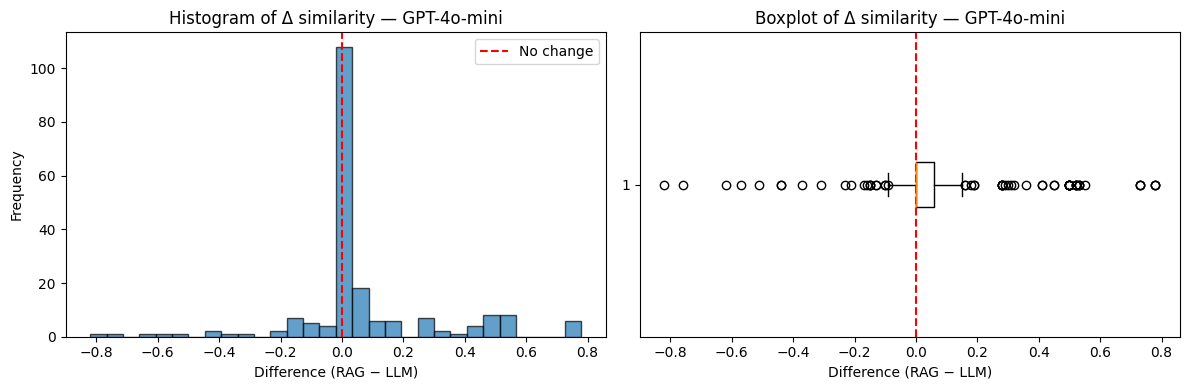

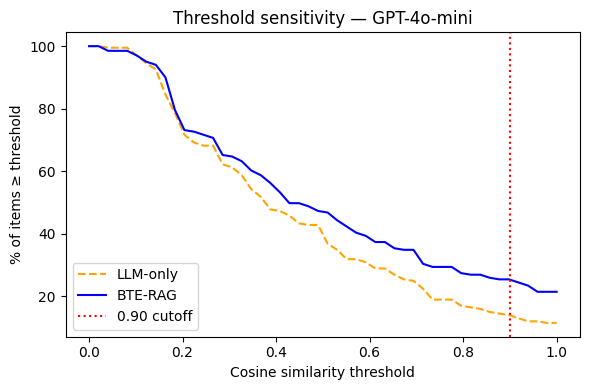


GPT-4o — Metabolite Similarity Analysis (N=201)

Wilcoxon signed-rank: median Δ=0.000, mean Δ=0.063, stat=1879.0, p=7.20e-04
Mean Δ = 0.063 (95% bootstrap CI: 0.030–0.095)
Median Δ = 0.000 (95% bootstrap CI: 0.000–0.000)
Cliff's delta = 0.065 (95% CI: -0.040–0.169), magnitude: negligible

--- Threshold Sensitivity (with Effect Sizes) ---


,Threshold,LLM_%≥thr,RAG_%≥thr,Δ_pp,Cliff_δ,95%_CI,Sig
0,0.85,16.4,27.4,10.9,0.109,"[0.05, 0.16]",yes
1,0.90,14.9,26.4,11.4,0.114,"[0.06, 0.17]",yes
2,0.95,11.4,25.9,14.4,0.144,"[0.09, 0.19]",yes



--- Distribution stats for GPT-4o ---
count    201.000000
mean       0.062537
std        0.229297
min       -0.820000
25%        0.000000
50%        0.000000
75%        0.070000
max        0.800000
dtype: float64
Proportion improved: 30.3%
Proportion worsened: 23.9%
Proportion unchanged: 45.8%


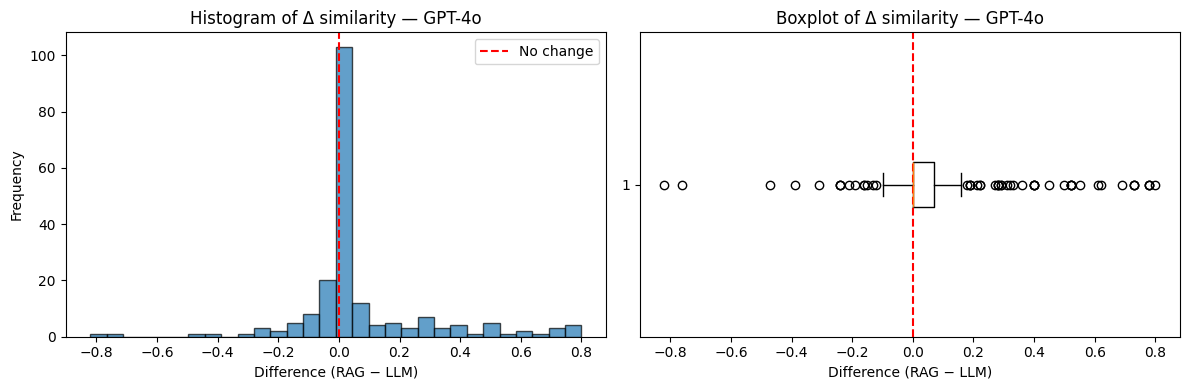

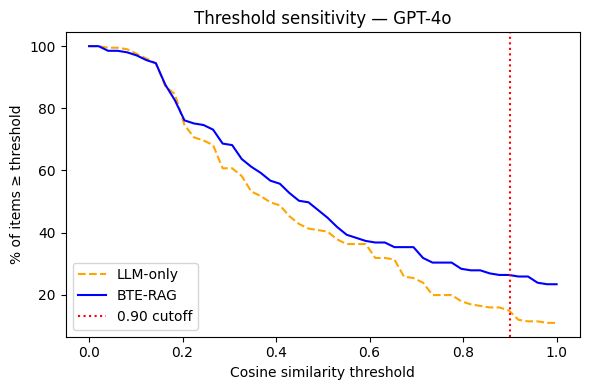

In [159]:
KEY_COLS = ["id", "question", "drug_name", "disease_name", "Drug_MeshID", "disease"]

# ANALYSIS FOR GPT-4o-mini
mini_results = run_metabolite_similarity_analysis(
    df_llm=gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite,
    df_rag=gpt4omini_2,
    key_cols=KEY_COLS,
    llm_cos_col="cosine_similarity",
    rag_cos_col="cosine_similarity_sim_80",
    model_label="GPT-4o-mini",
    show_plots=True
)

# ANALYSIS FOR GPT-4o
gpt4o_results = run_metabolite_similarity_analysis(
    df_llm=gpt_4o_prompt_testing_DMDB_chebi_metabolite, 
    df_rag=gpt4o_2,  
    key_cols=KEY_COLS,
    llm_cos_col="cosine_similarity",
    rag_cos_col="cosine_similarity_sim_80",
    model_label="GPT-4o",
    show_plots=True
)



## summary table

In [160]:

summary_table = create_summary_table([mini_results, gpt4o_results])
print("\n" + "="*70)
print("SUMMARY TABLE - Metabolite Benchmark")
print("="*70)
display(summary_table)


print("\n" + "="*70)
print("THRESHOLD COMPARISON - Enhanced with Effect Sizes")
print("="*70)
print("\nGPT-4o-mini:")
display(mini_results["threshold_table_enhanced"])
print("\nGPT-4o:")
display(gpt4o_results["threshold_table_enhanced"])


SUMMARY TABLE - Metabolite Benchmark


,Model,N,Mean Δ (95% CI),Median Δ (95% CI),Cliff's δ (95% CI),Effect Size,Wilcoxon p
0,GPT-4o-mini,201,0.066 (0.031–0.099),0.000 (0.000–0.000),0.239 (0.139–0.338),small,6.36e-05
1,GPT-4o,201,0.063 (0.030–0.095),0.000 (0.000–0.000),0.065 (-0.040–0.169),negligible,7.20e-04



THRESHOLD COMPARISON - Enhanced with Effect Sizes

GPT-4o-mini:


,Threshold,LLM_%≥thr,RAG_%≥thr,Δ_pp,Cliff_δ,95%_CI,Sig
0,0.85,15.4,26.4,10.9,0.109,"[0.05, 0.16]",yes
1,0.90,13.9,25.4,11.4,0.114,"[0.06, 0.17]",yes
2,0.95,11.9,23.4,11.4,0.114,"[0.06, 0.17]",yes



GPT-4o:


,Threshold,LLM_%≥thr,RAG_%≥thr,Δ_pp,Cliff_δ,95%_CI,Sig
0,0.85,16.4,27.4,10.9,0.109,"[0.05, 0.16]",yes
1,0.90,14.9,26.4,11.4,0.114,"[0.06, 0.17]",yes
2,0.95,11.4,25.9,14.4,0.144,"[0.09, 0.19]",yes


# Plots

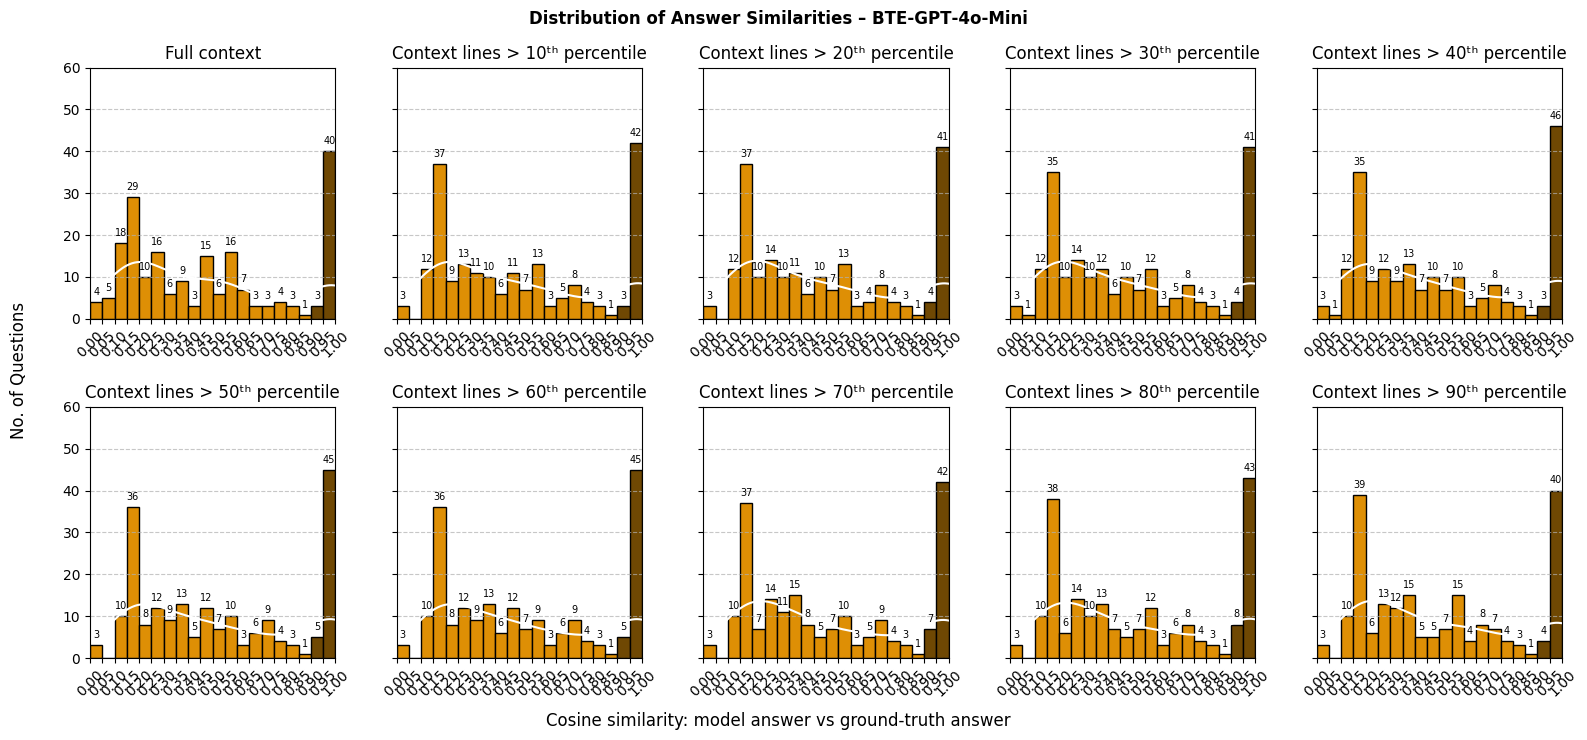

In [17]:
make_similarity_figure(gpt4omini_2, 'BTE‑GPT‑4o‑Mini',save_dir="figures/metabolite/")

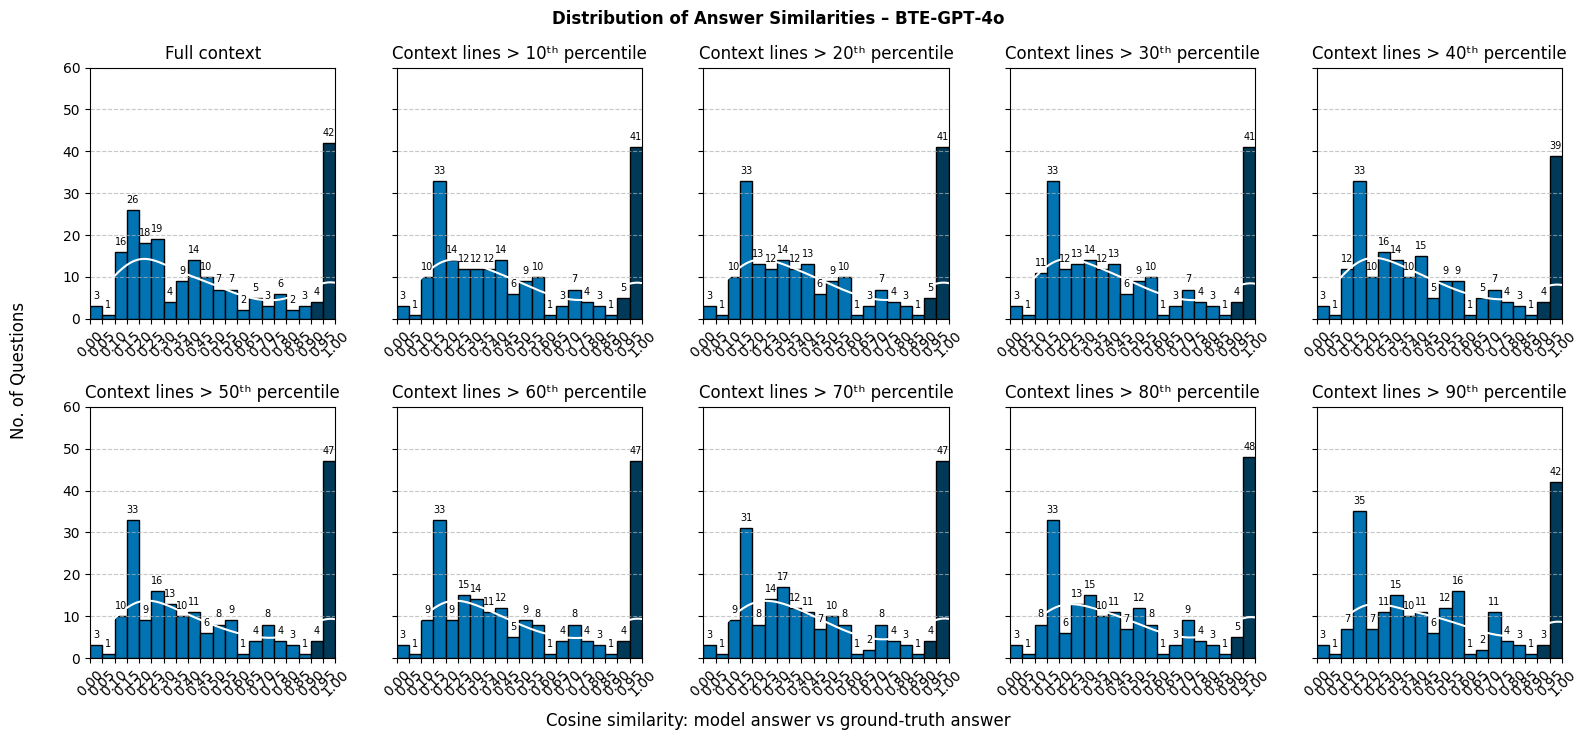

In [18]:
make_similarity_figure(gpt4o_2, 'BTE‑GPT‑4o',save_dir="figures/metabolite/")

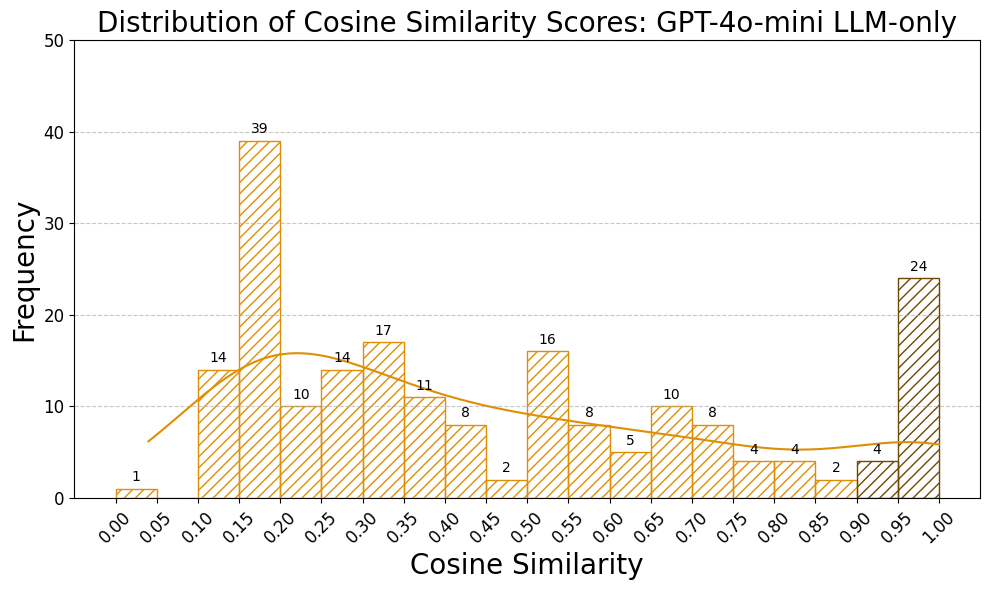

In [19]:
plot_score_distribution(
    gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite,
    model_name='GPT-4o-mini LLM-only',
    save_dir="figures/metabolite"
)

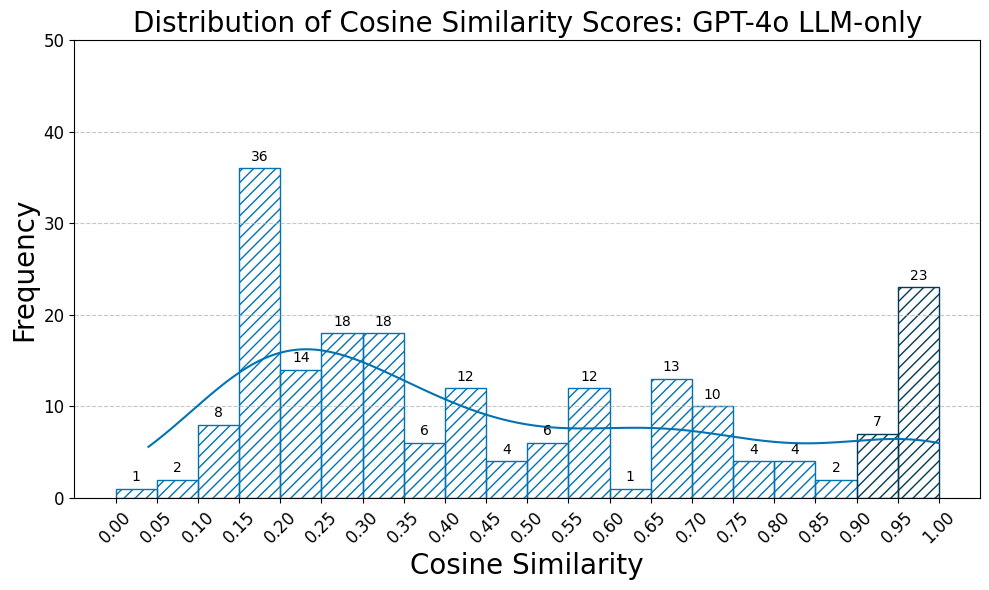

In [20]:
plot_score_distribution(
    gpt_4o_prompt_testing_DMDB_chebi_metabolite,
    model_name='GPT-4o LLM-only',
    save_dir="figures/metabolite"
)


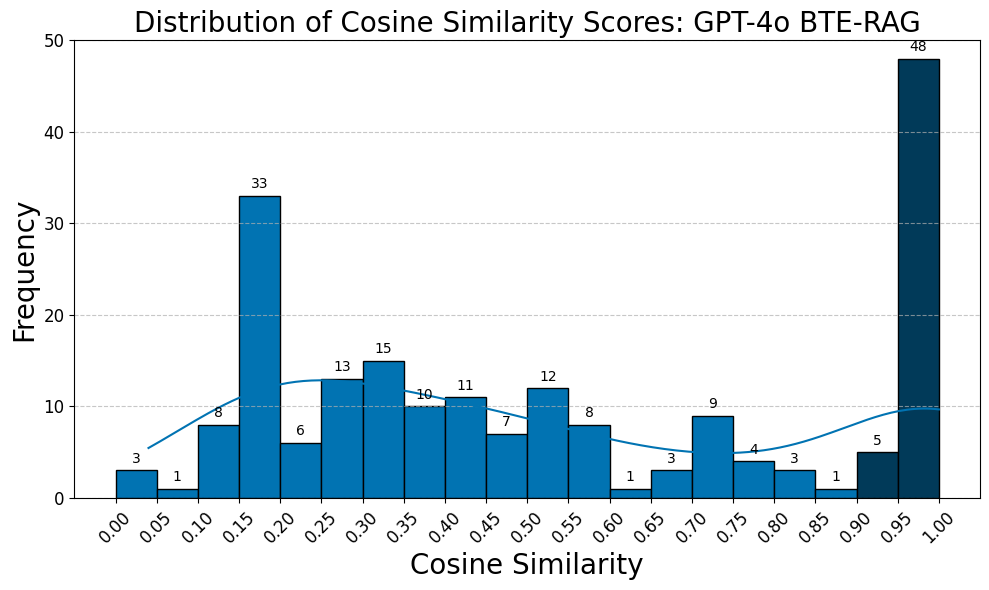

In [21]:
plot_score_distribution(
    gpt4o_2,
    score_col='cosine_similarity_sim_80',
    model_name='GPT-4o BTE-RAG',
    save_dir="figures/metabolite"
)

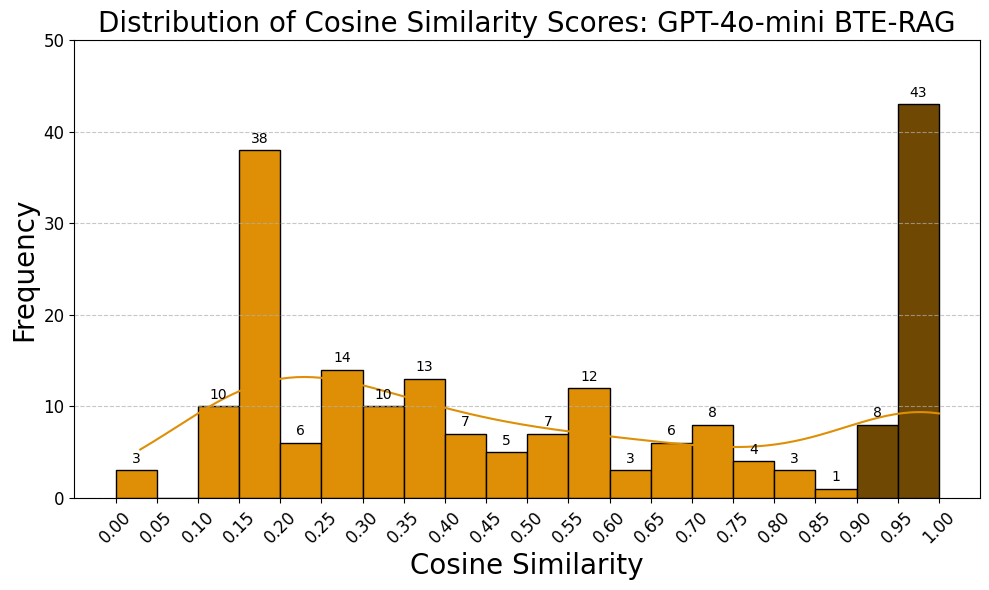

In [22]:
plot_score_distribution(
    gpt4omini_2,
    score_col='cosine_similarity_sim_80',
    model_name='GPT-4o-mini BTE-RAG',
    save_dir="figures/metabolite"
)

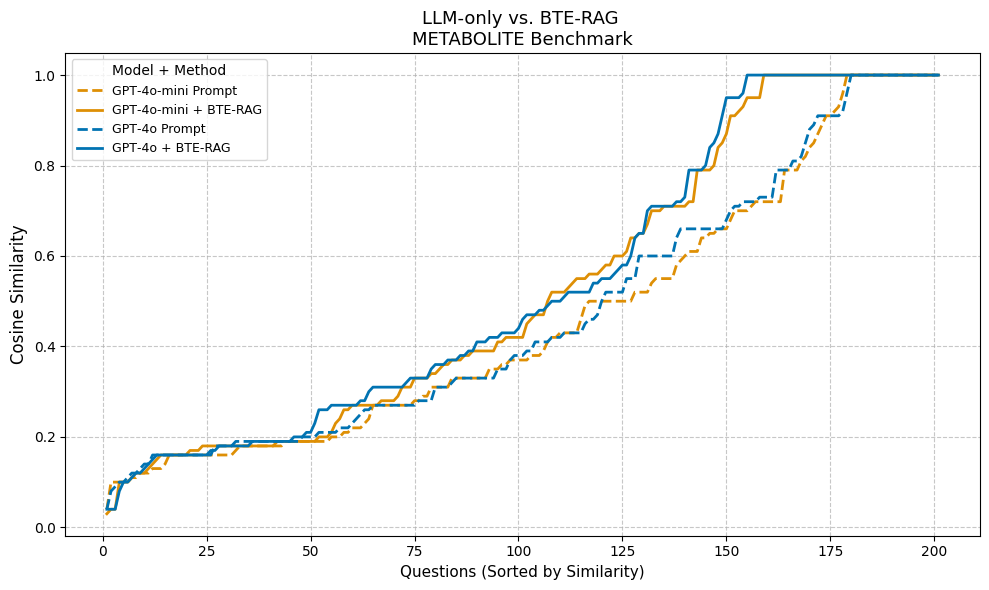

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- Data ---
dfs = [
    gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite,  # prompt‑only
    gpt4omini_2,                                       # BTE‑RAG
    gpt_4o_prompt_testing_DMDB_chebi_metabolite,       # prompt‑only
    gpt4o_2                                            # BTE‑RAG
]
labels = [
    'GPT‑4o‑mini Prompt',
    'GPT‑4o‑mini + BTE‑RAG',
    'GPT‑4o Prompt',
    'GPT‑4o + BTE‑RAG'
]
# ≥

# --- Colors & Styles ---
palette = sns.color_palette('colorblind', 2)           # [blue, orange]
colors = [palette[1], palette[1], palette[0], palette[0]]  # mini = orange, 4o = blue
line_styles = ['dashed', 'solid', 'dashed', 'solid']       # Prompt = dashed, RAG = solid

# --- Plot ---
plt.figure(figsize=(10, 6))

for df, label, color, style in zip(dfs, labels, colors, line_styles):
    # Select correct column
    col = 'cosine_similarity' if 'Prompt' in label else 'cosine_similarity_sim_80'
    if col not in df.columns:
        continue

    data = pd.to_numeric(df[col], errors='coerce').dropna()
    sorted_vals = np.sort(data)
    ranks = np.arange(1, len(sorted_vals) + 1)

    plt.plot(
        ranks, sorted_vals,
        label=label,
        color=color,
        linestyle=style,
        linewidth=2
    )

# --- Labels & Legend ---
plt.title(
    'LLM-only vs. BTE-RAG \nMETABOLITE Benchmark',
    fontsize=13
)
plt.xlabel('Questions (Sorted by Similarity)', fontsize=11)
plt.ylabel('Cosine Similarity', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Model + Method', fontsize=9)
plt.tight_layout()
plt.savefig("figures//metabolite/llm_vs_bte_rag_metabolite.svg", format="svg", bbox_inches="tight")

plt.show()

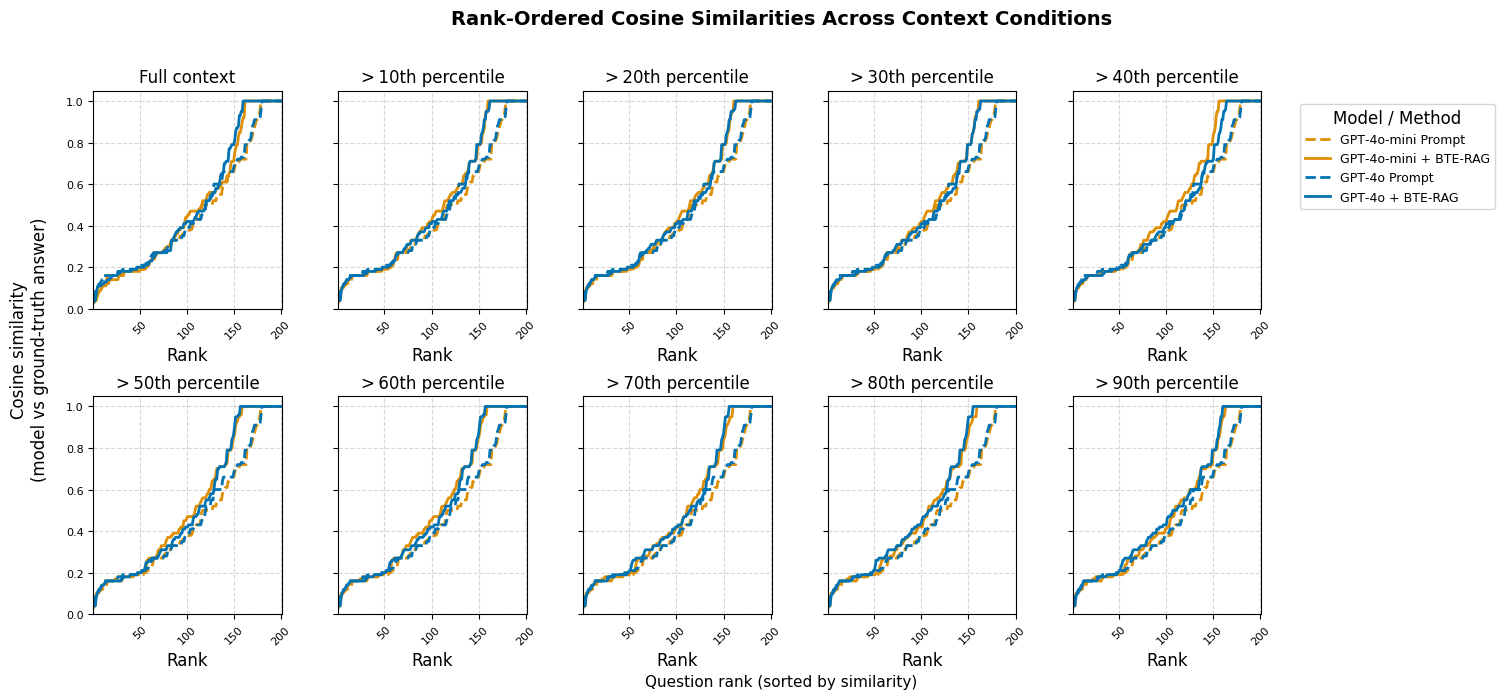

In [24]:
from math import ceil
dfs = [
    gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite,  # prompt‑only
    gpt4omini_2,                                       # BTE‑RAG
    gpt_4o_prompt_testing_DMDB_chebi_metabolite,       # prompt‑only
    gpt4o_2                                            # BTE‑RAG
]
labels    = [
    'GPT‑4o‑mini Prompt',
    'GPT‑4o‑mini + BTE‑RAG',
    'GPT‑4o Prompt',
    'GPT‑4o + BTE‑RAG'
]
is_prompt  = [True, False, True, False]   # True → only has "cosine_similarity"
palette    = sns.color_palette('colorblind', 2)        # orange, blue
colors     = [ palette[1], palette[1], palette[0], palette[0]]
linestyles = ['dashed', 'solid', 'dashed', 'solid']

# ---------------------------------------------------------------------
# 2.  Metric list – Full context + 10 → 90 %
# ---------------------------------------------------------------------
score_cols = ['cosine_similarity_NC'] + [
    f'cosine_similarity_sim_{t}' for t in range(10, 100, 10)
]                                           # 10 columns

# pretty_names = ['Full context'] + [f'≥ {t} % context' for t in range(10, 100, 10)]
pretty_names = ['Full context'] + [f'> {t}th percentile' for t in range(10, 100, 10)]


# ---------------------------------------------------------------------
# 3.  Grid geometry
# ---------------------------------------------------------------------
COLS_PER_ROW = 5
n_cols = COLS_PER_ROW
n_rows = ceil(len(score_cols) / n_cols)

fig_w = 3.2 * n_cols   # inches
fig_h = 3.4 * n_rows
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(fig_w, fig_h), sharey=True, constrained_layout=False
)
axes = axes.flatten()

# ---------------------------------------------------------------------
# 4.  Plotting loop
# ---------------------------------------------------------------------
for idx, (metric, nice_label) in enumerate(zip(score_cols, pretty_names)):
    ax = axes[idx]

    # track max length across datasets to set x‑limit
    max_len = 1

    for df, lbl, c, ls, prompt_flag in zip(dfs, labels, colors, linestyles, is_prompt):
        col = 'cosine_similarity' if prompt_flag else metric
        if col not in df.columns:
            continue

        data = pd.to_numeric(df[col], errors='coerce').dropna().sort_values()
        if data.empty:
            continue

        ranks = np.arange(1, len(data) + 1)
        max_len = max(max_len, len(data))

        ax.plot(
            ranks, data.values,
            label=lbl,
            color=c, linestyle=ls, linewidth=2
        )

    ax.set_title(nice_label, fontsize=12, pad=6)
    ax.set_xlim(1, max_len)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('Rank', fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

# hide any unused axes (if len(score_cols) < n_rows*n_cols)
for ax in axes[len(score_cols):]:
    ax.set_visible(False)

# ---------------------------------------------------------------------
# 5.  Global labels, title, legend, and margin tweaks
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.07, right=0.80,     # leave room for legend on the right
    bottom=0.11, top=0.88,
    wspace=0.30, hspace=0.40
)

fig.suptitle(
    'Rank‑Ordered Cosine Similarities Across Context Conditions',
    fontsize=14, fontweight='bold', y=1
)
fig.supxlabel('Question rank (sorted by similarity)', fontsize=11, y=0.0)
fig.supylabel('Cosine similarity\n(model vs ground‑truth answer)', fontsize=12, x=0.03,  y=0.5,    # centered vertically
    va='center', ha = 'center',
    rotation=90)

# One consolidated legend outside the grid
handles, legends = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legends,
    title='Model / Method',
    fontsize=9, title_fontsize=12,
    loc='upper left',
    bbox_to_anchor=(0.82, 0.87)
)

fig.savefig('figures/metabolite/ranked_similarity_curves.svg')
# fig.savefig('ranked_similarity_curves.png', dpi=300)

plt.show()

# Extra Plots

In [47]:
def plot_cumulative_comparison_corrected(baseline, rag, figsize=(10, 6)):
    """
    Cumulative distribution function comparison (SURVIVAL CURVE)
    Shows % of questions that achieve AT LEAST each similarity level
    """
    plt.figure(figsize=figsize)
    
    # Sort in DESCENDING order
    baseline_sorted = np.sort(baseline)[::-1]
    rag_sorted = np.sort(rag)[::-1]
    
    # Calculate % achieving AT LEAST this score
    cum_pct = np.arange(1, len(baseline_sorted) + 1) / len(baseline_sorted) * 100
    
    plt.plot(baseline_sorted, cum_pct, '--', color='orange', linewidth=2.5, label='LLM-only')
    plt.plot(rag_sorted, cum_pct, '-', color='blue', linewidth=2.5, label='BTE-RAG')
    
    # Highlight key threshold
    plt.axvline(0.90, color='red', linestyle=':', linewidth=2, label='0.90 threshold')
    
    # Add annotations at 0.90
    llm_pct_at_90 = (baseline >= 0.90).mean() * 100
    rag_pct_at_90 = (rag >= 0.90).mean() * 100
    
    plt.annotate(f'LLM: {llm_pct_at_90:.1f}%\nat ≥0.90', 
                xy=(0.90, llm_pct_at_90), xytext=(0.80, llm_pct_at_90 - 5),
                arrowprops=dict(arrowstyle='->', color='orange'), fontsize=10, color='orange')
    plt.annotate(f'RAG: {rag_pct_at_90:.1f}%\nat ≥0.90', 
                xy=(0.90, rag_pct_at_90), xytext=(0.80, rag_pct_at_90 + 5),
                arrowprops=dict(arrowstyle='->', color='blue'), fontsize=10, color='blue')
    
    plt.xlabel('Cosine Similarity', fontsize=13)
    plt.ylabel('Percentage of Questions (%) Achieving ≥ This Score', fontsize=13)
    plt.title('What % of Questions Achieve At Least This Similarity?', fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [82]:
def plot_cumulative_comparison_corrected(baseline, rag, figsize=(10, 6)):
    """
    Cumulative distribution function comparison (SURVIVAL CURVE)
    Shows % of questions that achieve AT LEAST each similarity level
    """
    plt.figure(figsize=figsize)
    
    # Sort in DESCENDING order
    baseline_sorted = np.sort(baseline)[::-1]
    rag_sorted = np.sort(rag)[::-1]
    
    # Calculate % achieving AT LEAST this score
    cum_pct = np.arange(1, len(baseline_sorted) + 1) / len(baseline_sorted) * 100
    
    plt.plot(baseline_sorted, cum_pct, '--', color='orange', linewidth=2.5, label='LLM-only')
    plt.plot(rag_sorted, cum_pct, '-', color='blue', linewidth=2.5, label='BTE-RAG')
    
    # Highlight key threshold
    plt.axvline(0.90, color='red', linestyle=':', linewidth=2, label='0.90 threshold')
    
    # Add annotations at 0.90
    llm_pct_at_90 = (baseline >= 0.90).mean() * 100
    rag_pct_at_90 = (rag >= 0.90).mean() * 100
    
    plt.annotate(f'LLM: {llm_pct_at_90:.1f}%\nat ≥0.90', 
                xy=(0.90, llm_pct_at_90), xytext=(0.70, llm_pct_at_90 - 15),
                arrowprops=dict(arrowstyle='->', color='orange'), fontsize=18, color='orange')
    plt.annotate(f'RAG: {rag_pct_at_90:.1f}%\nat ≥0.90', 
                xy=(0.90, rag_pct_at_90), xytext=(0.70, rag_pct_at_90 + 15),
                arrowprops=dict(arrowstyle='->', color='blue'), fontsize=18, color='blue')
    
    plt.xlabel('Cosine Similarity', fontsize=18)
    plt.ylabel('Percentage of Questions (%) Achieving ≥ This Score', fontsize=12)
    plt.title('What % of Questions Achieve At Least This Similarity?', fontsize=18, fontweight='bold')
    plt.legend(fontsize=18)
    plt.grid(alpha=0.3)
    
    # Adjust layout to accommodate horizontal y-axis label
    plt.tight_layout()
    # plt.subplots_adjust(left=0.25)  # Make room for horizontal y-label
    
    plt.show()

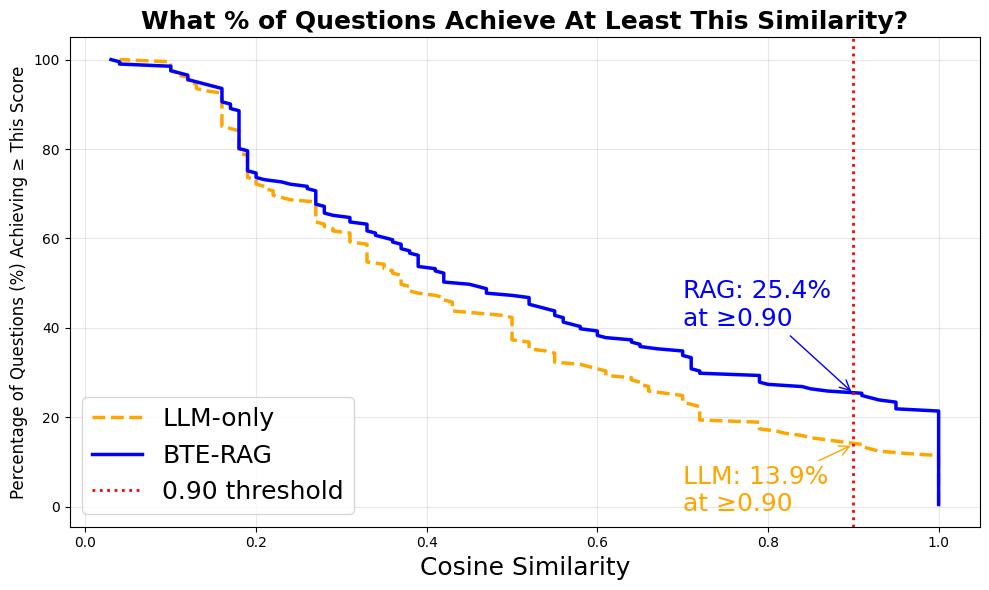

In [83]:
key_cols = ["id", "question", "drug_name", "disease_name", "Drug_MeshID", "disease"]
df_llm = gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite[key_cols + ['llm_answer_prompt_test_answer', "cosine_similarity"]].copy()
df_rag = gpt4omini_2[key_cols + ['output_sim_80_answer', "cosine_similarity_sim_80", "metabolite_name"]].copy()
df = pd.merge(df_llm, df_rag, how="inner", on=key_cols)
df = df.rename(columns={"cosine_similarity": "llm_cosine", "cosine_similarity_sim_80": "rag_cosine"})

baseline = df["llm_cosine"].to_numpy()
rag = df["rag_cosine"].to_numpy()

# RUN THE PLOT
plot_cumulative_comparison_corrected(baseline, rag)

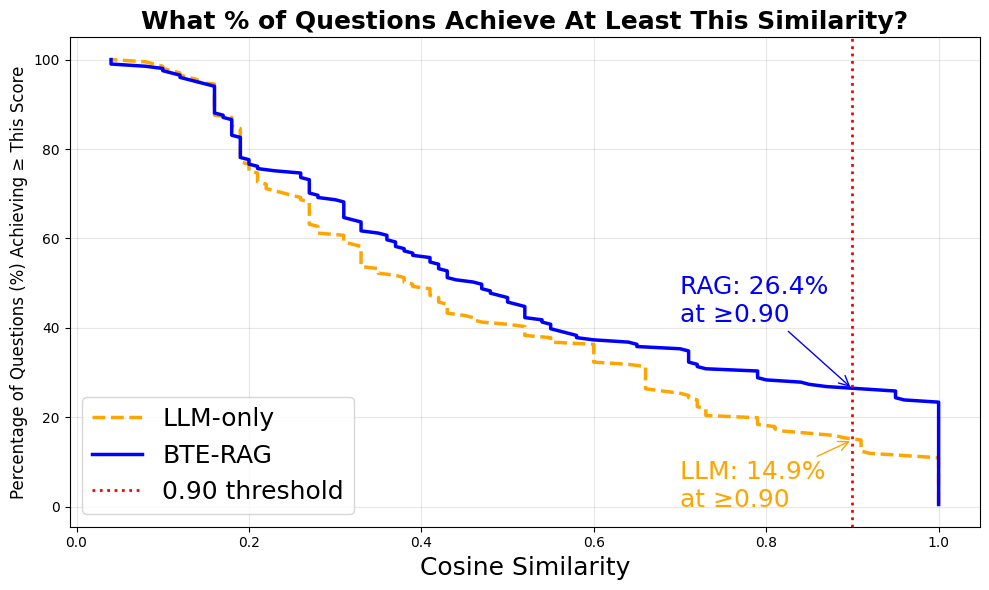

In [84]:
key_cols = ["id", "question", "drug_name", "disease_name", "Drug_MeshID", "disease"]
df_llm = gpt_4o_prompt_testing_DMDB_chebi_metabolite[key_cols + ['llm_answer_prompt_test_answer', "cosine_similarity"]].copy()
df_rag = gpt4o_2[key_cols + ['output_sim_80_answer', "cosine_similarity_sim_80", "metabolite_name"]].copy()
df = pd.merge(df_llm, df_rag, how="inner", on=key_cols)
df = df.rename(columns={"cosine_similarity": "llm_cosine", "cosine_similarity_sim_80": "rag_cosine"})

baseline = df["llm_cosine"].to_numpy()
rag = df["rag_cosine"].to_numpy()

# RUN THE PLOT
plot_cumulative_comparison_corrected(baseline, rag)

In [85]:
1+1

2

## stats 

In [90]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu, ttest_rel
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns


def threshold_performance_table(baseline, rag, thresholds=[0.80, 0.85, 0.90, 0.95, 0.99]):
    """
    Create a comprehensive table showing performance at different similarity thresholds
    
    Parameters:
    -----------
    baseline : array-like
        LLM-only cosine similarities
    rag : array-like
        BTE-RAG cosine similarities
    thresholds : list
        List of similarity thresholds to evaluate
        
    Returns:
    --------
    pd.DataFrame : Table with counts, percentages, and improvements at each threshold
    """
    n = len(baseline)
    rows = []
    
    for thr in thresholds:
        llm_count = (baseline >= thr).sum()
        rag_count = (rag >= thr).sum()
        
        llm_pct = (baseline >= thr).mean() * 100
        rag_pct = (rag >= thr).mean() * 100
        
        absolute_gain = rag_count - llm_count
        percentage_point_gain = rag_pct - llm_pct
        relative_improvement = ((rag_pct - llm_pct) / llm_pct * 100) if llm_pct > 0 else np.inf
        
        rows.append({
            'Threshold': f'≥{thr:.2f}',
            'LLM_Count': llm_count,
            'RAG_Count': rag_count,
            'LLM_%': f'{llm_pct:.1f}%',
            'RAG_%': f'{rag_pct:.1f}%',
            'Δ_Count': f'+{absolute_gain}' if absolute_gain >= 0 else f'{absolute_gain}',
            'Δ_pp': f'+{percentage_point_gain:.1f}' if percentage_point_gain >= 0 else f'{percentage_point_gain:.1f}',
            'Relative_Improvement': f'+{relative_improvement:.1f}%' if relative_improvement >= 0 else f'{relative_improvement:.1f}%'
        })
    
    df = pd.DataFrame(rows)
    return df


def comprehensive_statistical_tests(baseline, rag, alpha=0.05):
    """
    Perform comprehensive statistical tests comparing baseline and RAG
    
    Parameters:
    -----------
    baseline : array-like
        LLM-only cosine similarities
    rag : array-like
        BTE-RAG cosine similarities
    alpha : float
        Significance level (default: 0.05)
        
    Returns:
    --------
    dict : Dictionary containing all test results
    """
    diffs = rag - baseline
    
    results = {}
    
    # 1. Descriptive Statistics
    results['descriptive'] = {
        'n_samples': len(baseline),
        'llm_mean': baseline.mean(),
        'llm_std': baseline.std(),
        'llm_median': np.median(baseline),
        'llm_q25': np.percentile(baseline, 25),
        'llm_q75': np.percentile(baseline, 75),
        'rag_mean': rag.mean(),
        'rag_std': rag.std(),
        'rag_median': np.median(rag),
        'rag_q25': np.percentile(rag, 25),
        'rag_q75': np.percentile(rag, 75),
        'diff_mean': diffs.mean(),
        'diff_median': np.median(diffs),
        'diff_std': diffs.std(),
    }
    
    # 2. Wilcoxon Signed-Rank Test (paired, non-parametric)
    try:
        w_stat, w_pval = wilcoxon(diffs, alternative='greater')  # Test if RAG > LLM
        results['wilcoxon'] = {
            'statistic': w_stat,
            'p_value': w_pval,
            'significant': w_pval < alpha,
            'interpretation': 'RAG significantly better' if w_pval < alpha else 'No significant difference'
        }
    except Exception as e:
        results['wilcoxon'] = {'error': str(e)}
    
    # 3. Paired t-test (parametric)
    try:
        t_stat, t_pval = ttest_rel(rag, baseline, alternative='greater')
        results['paired_ttest'] = {
            'statistic': t_stat,
            'p_value': t_pval,
            'significant': t_pval < alpha,
            'interpretation': 'RAG significantly better' if t_pval < alpha else 'No significant difference'
        }
    except Exception as e:
        results['paired_ttest'] = {'error': str(e)}
    
    # 4. Effect Size: Cohen's d
    cohens_d = diffs.mean() / diffs.std()
    results['cohens_d'] = {
        'value': cohens_d,
        'magnitude': get_cohens_d_magnitude(cohens_d)
    }
    
    # 5. Effect Size: Cliff's Delta
    cliff_delta = calculate_cliffs_delta(rag, baseline)
    results['cliffs_delta'] = {
        'value': cliff_delta,
        'magnitude': get_cliffs_delta_magnitude(cliff_delta)
    }
    
    # 6. Improvement Statistics
    results['improvements'] = {
        'n_improved': (diffs > 0).sum(),
        'n_worsened': (diffs < 0).sum(),
        'n_unchanged': (diffs == 0).sum(),
        'pct_improved': (diffs > 0).mean() * 100,
        'pct_worsened': (diffs < 0).mean() * 100,
        'pct_unchanged': (diffs == 0).mean() * 100,
    }
    
    # 7. Sign Test
    n_pos = (diffs > 0).sum()
    n_total = len(diffs[diffs != 0])  # Exclude ties
    try:
        # Try new API (SciPy >= 1.7.0)
        from scipy.stats import binomtest
        sign_result = binomtest(n_pos, n_total, 0.5, alternative='greater')
        sign_pval = sign_result.pvalue
    except ImportError:
        # Fall back to old API (SciPy < 1.7.0)
        sign_pval = stats.binom_test(n_pos, n_total, 0.5, alternative='greater')
    
    results['sign_test'] = {
        'n_positive': n_pos,
        'n_total': n_total,
        'p_value': sign_pval,
        'significant': sign_pval < alpha
    }
    
    return results


def calculate_cliffs_delta(x, y):
    """Calculate Cliff's Delta effect size"""
    x = np.asarray(x)
    y = np.asarray(y)
    
    n_x = len(x)
    n_y = len(y)
    
    # Count comparisons
    gt = 0  # x > y
    lt = 0  # x < y
    
    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)
    
    delta = (gt - lt) / (n_x * n_y)
    return delta


def get_cliffs_delta_magnitude(delta):
    """Get magnitude interpretation of Cliff's Delta"""
    abs_delta = abs(delta)
    if abs_delta < 0.147:
        return "negligible"
    elif abs_delta < 0.33:
        return "small"
    elif abs_delta < 0.474:
        return "medium"
    else:
        return "large"


def get_cohens_d_magnitude(d):
    """Get magnitude interpretation of Cohen's d"""
    abs_d = abs(d)
    if abs_d < 0.2:
        return "negligible"
    elif abs_d < 0.5:
        return "small"
    elif abs_d < 0.8:
        return "medium"
    else:
        return "large"


def print_statistical_summary(baseline, rag, thresholds=[0.80, 0.85, 0.90, 0.95, 0.99]):
    """
    Print a comprehensive statistical summary with formatted output
    
    Parameters:
    -----------
    baseline : array-like
        LLM-only cosine similarities
    rag : array-like
        BTE-RAG cosine similarities
    thresholds : list
        List of similarity thresholds to evaluate
    """
    print("="*80)
    print("COMPREHENSIVE STATISTICAL ANALYSIS: LLM-only vs BTE-RAG")
    print("="*80)
    
    # Get all statistics
    stats_results = comprehensive_statistical_tests(baseline, rag)
    
    # 1. Sample Size
    print(f"\n{'='*80}")
    print("1. SAMPLE SIZE")
    print(f"{'='*80}")
    print(f"Number of questions: {stats_results['descriptive']['n_samples']}")
    
    # 2. Descriptive Statistics
    print(f"\n{'='*80}")
    print("2. DESCRIPTIVE STATISTICS")
    print(f"{'='*80}")
    desc = stats_results['descriptive']
    print(f"\nLLM-only:")
    print(f"  Mean:   {desc['llm_mean']:.4f}")
    print(f"  Median: {desc['llm_median']:.4f}")
    print(f"  SD:     {desc['llm_std']:.4f}")
    print(f"  Q1-Q3:  {desc['llm_q25']:.4f} - {desc['llm_q75']:.4f}")
    
    print(f"\nBTE-RAG:")
    print(f"  Mean:   {desc['rag_mean']:.4f}")
    print(f"  Median: {desc['rag_median']:.4f}")
    print(f"  SD:     {desc['rag_std']:.4f}")
    print(f"  Q1-Q3:  {desc['rag_q25']:.4f} - {desc['rag_q75']:.4f}")
    
    print(f"\nDifference (RAG - LLM):")
    print(f"  Mean difference:   {desc['diff_mean']:.4f} ({desc['diff_mean']/desc['llm_mean']*100:.1f}% relative)")
    print(f"  Median difference: {desc['diff_median']:.4f}")
    print(f"  SD of differences: {desc['diff_std']:.4f}")
    
    # 3. Improvement Summary
    print(f"\n{'='*80}")
    print("3. QUESTION-LEVEL CHANGES")
    print(f"{'='*80}")
    imp = stats_results['improvements']
    print(f"Improved:  {imp['n_improved']:4d} questions ({imp['pct_improved']:.1f}%)")
    print(f"Worsened:  {imp['n_worsened']:4d} questions ({imp['pct_worsened']:.1f}%)")
    print(f"Unchanged: {imp['n_unchanged']:4d} questions ({imp['pct_unchanged']:.1f}%)")
    
    # 4. Statistical Tests
    print(f"\n{'='*80}")
    print("4. STATISTICAL SIGNIFICANCE TESTS")
    print(f"{'='*80}")
    
    if 'wilcoxon' in stats_results and 'error' not in stats_results['wilcoxon']:
        w = stats_results['wilcoxon']
        print(f"\nWilcoxon Signed-Rank Test (non-parametric, paired):")
        print(f"  Statistic: {w['statistic']:.2f}")
        print(f"  P-value:   {w['p_value']:.2e}")
        print(f"  Result:    {w['interpretation']}")
        print(f"  {'✓ SIGNIFICANT' if w['significant'] else '✗ NOT SIGNIFICANT'} (α=0.05)")
    
    if 'paired_ttest' in stats_results and 'error' not in stats_results['paired_ttest']:
        t = stats_results['paired_ttest']
        print(f"\nPaired t-test (parametric, paired):")
        print(f"  Statistic: {t['statistic']:.4f}")
        print(f"  P-value:   {t['p_value']:.2e}")
        print(f"  Result:    {t['interpretation']}")
        print(f"  {'✓ SIGNIFICANT' if t['significant'] else '✗ NOT SIGNIFICANT'} (α=0.05)")
    
    if 'sign_test' in stats_results:
        s = stats_results['sign_test']
        print(f"\nSign Test (non-parametric, paired):")
        print(f"  Positive differences: {s['n_positive']}/{s['n_total']}")
        print(f"  P-value: {s['p_value']:.2e}")
        print(f"  {'✓ SIGNIFICANT' if s['significant'] else '✗ NOT SIGNIFICANT'} (α=0.05)")
    
    # 5. Effect Sizes
    print(f"\n{'='*80}")
    print("5. EFFECT SIZES")
    print(f"{'='*80}")
    
    if 'cohens_d' in stats_results:
        cd = stats_results['cohens_d']
        print(f"\nCohen's d:")
        print(f"  Value:     {cd['value']:.4f}")
        print(f"  Magnitude: {cd['magnitude']}")
    
    if 'cliffs_delta' in stats_results:
        cliff = stats_results['cliffs_delta']
        print(f"\nCliff's Delta:")
        print(f"  Value:     {cliff['value']:.4f}")
        print(f"  Magnitude: {cliff['magnitude']}")
    
    # 6. Threshold Performance Table
    print(f"\n{'='*80}")
    print("6. PERFORMANCE AT DIFFERENT THRESHOLDS")
    print(f"{'='*80}\n")
    
    threshold_table = threshold_performance_table(baseline, rag, thresholds=thresholds)
    print(threshold_table.to_string(index=False))
    
    # 7. Summary Statement
    print(f"\n{'='*80}")
    print("7. SUMMARY STATEMENT FOR THESIS")
    print(f"{'='*80}")
    
    mean_diff = desc['diff_mean']
    rel_imp = mean_diff / desc['llm_mean'] * 100
    
    llm_90 = (baseline >= 0.90).mean() * 100
    rag_90 = (rag >= 0.90).mean() * 100
    pp_gain = rag_90 - llm_90
    rel_90 = (pp_gain / llm_90 * 100) if llm_90 > 0 else 0
    
    w_pval = stats_results['wilcoxon']['p_value'] if 'wilcoxon' in stats_results else None
    
    print(f"""
BTE-RAG significantly outperformed LLM-only across all metrics (N={desc['n_samples']} questions). 
The mean cosine similarity increased from {desc['llm_mean']:.3f} to {desc['rag_mean']:.3f} 
(Δ = {mean_diff:.3f}, +{rel_imp:.1f}% relative improvement; Wilcoxon p = {w_pval:.2e}).

At the high-fidelity threshold (≥0.90), BTE-RAG achieved acceptable answers for {rag_90:.1f}% 
of questions compared to {llm_90:.1f}% for LLM-only, representing a {pp_gain:.1f} percentage 
point gain (+{rel_90:.0f}% relative improvement). 

{imp['pct_improved']:.1f}% of questions showed improvement, {imp['pct_worsened']:.1f}% worsened, 
and {imp['pct_unchanged']:.1f}% remained unchanged. The effect size was {stats_results['cliffs_delta']['magnitude']} 
(Cliff's δ = {stats_results['cliffs_delta']['value']:.3f}).
    """)
    
    print("="*80)
    
    return stats_results, threshold_table


def create_summary_statistics_table(baseline, rag):
    """
    Create a publication-ready summary statistics table
    
    Returns:
    --------
    pd.DataFrame : Formatted table for thesis/publication
    """
    data = {
        'Metric': [
            'N',
            'Mean ± SD',
            'Median [IQR]',
            'Min - Max',
            'Mean Difference',
            'Wilcoxon p-value',
            "Cliff's Delta",
            "Cohen's d"
        ],
        'LLM-only': [
            f'{len(baseline)}',
            f'{baseline.mean():.3f} ± {baseline.std():.3f}',
            f'{np.median(baseline):.3f} [{np.percentile(baseline, 25):.3f}-{np.percentile(baseline, 75):.3f}]',
            f'{baseline.min():.3f} - {baseline.max():.3f}',
            '—',
            '—',
            '—',
            '—'
        ]
    }
    
    # Calculate statistics
    diffs = rag - baseline
    w_stat, w_pval = wilcoxon(diffs, alternative='greater')
    cliff = calculate_cliffs_delta(rag, baseline)
    cohens = diffs.mean() / diffs.std()
    
    data['BTE-RAG'] = [
        f'{len(rag)}',
        f'{rag.mean():.3f} ± {rag.std():.3f}',
        f'{np.median(rag):.3f} [{np.percentile(rag, 25):.3f}-{np.percentile(rag, 75):.3f}]',
        f'{rag.min():.3f} - {rag.max():.3f}',
        f'{diffs.mean():.3f} ({diffs.mean()/baseline.mean()*100:+.1f}%)',
        f'{w_pval:.2e}',
        f'{cliff:.3f} ({get_cliffs_delta_magnitude(cliff)})',
        f'{cohens:.3f} ({get_cohens_d_magnitude(cohens)})'
    ]
    
    return pd.DataFrame(data)


# Example usage function
def analyze_comparison(baseline, rag, thresholds=[0.80, 0.85, 0.90, 0.95, 0.99]):
    """
    One-stop function to run all analyses
    
    Parameters:
    -----------
    baseline : array-like
        LLM-only cosine similarities
    rag : array-like
        BTE-RAG cosine similarities
    thresholds : list
        List of similarity thresholds to evaluate
    
    Returns:
    --------
    tuple : (stats_results, threshold_table, summary_table)
    """
    print("Running comprehensive statistical analysis...\n")
    
    # Print full summary
    stats_results, threshold_table = print_statistical_summary(baseline, rag, thresholds)
    
    # Create publication table
    print("\n" + "="*80)
    print("PUBLICATION-READY SUMMARY TABLE")
    print("="*80 + "\n")
    summary_table = create_summary_statistics_table(baseline, rag)
    print(summary_table.to_string(index=False))
    print()
    
    return stats_results, threshold_table, summary_table

In [91]:
key_cols = ["id", "question", "drug_name", "disease_name", "Drug_MeshID", "disease"]
df_llm = gpt_4o_mini_prompt_testing_DMDB_chebi_metabolite[key_cols + ['llm_answer_prompt_test_answer', "cosine_similarity"]].copy()
df_rag = gpt4omini_2[key_cols + ['output_sim_80_answer', "cosine_similarity_sim_80", "metabolite_name"]].copy()
df = pd.merge(df_llm, df_rag, how="inner", on=key_cols)
df = df.rename(columns={"cosine_similarity": "llm_cosine", "cosine_similarity_sim_80": "rag_cosine"})

baseline = df["llm_cosine"].to_numpy()
rag = df["rag_cosine"].to_numpy()

In [92]:
stats_results, threshold_table, summary_table = analyze_comparison(baseline, rag)


Running comprehensive statistical analysis...

COMPREHENSIVE STATISTICAL ANALYSIS: LLM-only vs BTE-RAG

1. SAMPLE SIZE
Number of questions: 201

2. DESCRIPTIVE STATISTICS

LLM-only:
  Mean:   0.4606
  Median: 0.3700
  SD:     0.2901
  Q1-Q3:  0.1900 - 0.6800

BTE-RAG:
  Mean:   0.5263
  Median: 0.4200
  SD:     0.3263
  Q1-Q3:  0.1900 - 0.9100

Difference (RAG - LLM):
  Mean difference:   0.0656 (14.2% relative)
  Median difference: 0.0000
  SD of differences: 0.2430

3. QUESTION-LEVEL CHANGES
Improved:    81 questions (40.3%)
Worsened:    33 questions (16.4%)
Unchanged:   87 questions (43.3%)

4. STATISTICAL SIGNIFICANCE TESTS

Wilcoxon Signed-Rank Test (non-parametric, paired):
  Statistic: 4691.50
  P-value:   3.18e-05
  Result:    RAG significantly better
  ✓ SIGNIFICANT (α=0.05)

Paired t-test (parametric, paired):
  Statistic: 3.8187
  P-value:   8.95e-05
  Result:    RAG significantly better
  ✓ SIGNIFICANT (α=0.05)

Sign Test (non-parametric, paired):
  Positive differences: 81

In [93]:
key_cols = ["id", "question", "drug_name", "disease_name", "Drug_MeshID", "disease"]
df_llm = gpt_4o_prompt_testing_DMDB_chebi_metabolite[key_cols + ['llm_answer_prompt_test_answer', "cosine_similarity"]].copy()
df_rag = gpt4o_2[key_cols + ['output_sim_80_answer', "cosine_similarity_sim_80", "metabolite_name"]].copy()
df = pd.merge(df_llm, df_rag, how="inner", on=key_cols)
df = df.rename(columns={"cosine_similarity": "llm_cosine", "cosine_similarity_sim_80": "rag_cosine"})

baseline = df["llm_cosine"].to_numpy()
rag = df["rag_cosine"].to_numpy()

In [94]:
stats_results, threshold_table, summary_table = analyze_comparison(baseline, rag)


Running comprehensive statistical analysis...

COMPREHENSIVE STATISTICAL ANALYSIS: LLM-only vs BTE-RAG

1. SAMPLE SIZE
Number of questions: 201

2. DESCRIPTIVE STATISTICS

LLM-only:
  Mean:   0.4709
  Median: 0.3800
  SD:     0.2912
  Q1-Q3:  0.2000 - 0.7000

BTE-RAG:
  Mean:   0.5334
  Median: 0.4600
  SD:     0.3267
  Q1-Q3:  0.2300 - 0.9500

Difference (RAG - LLM):
  Mean difference:   0.0625 (13.3% relative)
  Median difference: 0.0000
  SD of differences: 0.2287

3. QUESTION-LEVEL CHANGES
Improved:    61 questions (30.3%)
Worsened:    48 questions (23.9%)
Unchanged:   92 questions (45.8%)

4. STATISTICAL SIGNIFICANCE TESTS

Wilcoxon Signed-Rank Test (non-parametric, paired):
  Statistic: 4116.00
  P-value:   3.60e-04
  Result:    RAG significantly better
  ✓ SIGNIFICANT (α=0.05)

Paired t-test (parametric, paired):
  Statistic: 3.8667
  P-value:   7.46e-05
  Result:    RAG significantly better
  ✓ SIGNIFICANT (α=0.05)

Sign Test (non-parametric, paired):
  Positive differences: 61

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

def plot_side_by_side_histograms(baseline, rag, bins=30, figsize=(12, 5)):
    """
    Side-by-side histograms showing distribution of similarities
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    
    # LLM-only
    axes[0].hist(baseline, bins=bins, color='orange', alpha=0.7, edgecolor='black')
    axes[0].axvline(baseline.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {baseline.mean():.3f}')
    axes[0].axvline(np.median(baseline), color='red', linestyle=':', linewidth=2, label=f'Median: {np.median(baseline):.3f}')
    axes[0].set_xlabel('Cosine Similarity', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('LLM-only', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3)
    
    # BTE-RAG
    axes[1].hist(rag, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    axes[1].axvline(rag.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {rag.mean():.3f}')
    axes[1].axvline(np.median(rag), color='red', linestyle=':', linewidth=2, label=f'Median: {np.median(rag):.3f}')
    axes[1].set_xlabel('Cosine Similarity', fontsize=12)
    axes[1].set_title('BTE-RAG', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_overlapping_distributions(baseline, rag, figsize=(10, 6)):
    """
    Overlapping density plots with shaded regions
    """
    plt.figure(figsize=figsize)
    
    # Plot distributions
    plt.hist(baseline, bins=30, alpha=0.5, color='orange', label='LLM-only', density=True, edgecolor='black')
    plt.hist(rag, bins=30, alpha=0.5, color='blue', label='BTE-RAG', density=True, edgecolor='black')
    
    # Add KDE curves
    from scipy.stats import gaussian_kde
    kde_llm = gaussian_kde(baseline)
    kde_rag = gaussian_kde(rag)
    x_range = np.linspace(min(baseline.min(), rag.min()), 1, 200)
    plt.plot(x_range, kde_llm(x_range), color='darkorange', linewidth=2, linestyle='--')
    plt.plot(x_range, kde_rag(x_range), color='darkblue', linewidth=2, linestyle='-')
    
    # Add vertical lines for means
    plt.axvline(baseline.mean(), color='orange', linestyle='--', linewidth=2, alpha=0.8, label=f'LLM mean: {baseline.mean():.3f}')
    plt.axvline(rag.mean(), color='blue', linestyle='--', linewidth=2, alpha=0.8, label=f'RAG mean: {rag.mean():.3f}')
    
    # Highlight high-fidelity region (e.g., >0.90)
    plt.axvspan(0.90, 1.0, alpha=0.2, color='green', label='High-fidelity region (≥0.90)')
    
    plt.xlabel('Cosine Similarity', fontsize=13)
    plt.ylabel('Density', fontsize=13)
    plt.title('Distribution of Answer Similarities: LLM-only vs BTE-RAG', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_paired_scatter(baseline, rag, figsize=(8, 8)):
    """
    Scatter plot showing paired improvements
    """
    plt.figure(figsize=figsize)
    
    # Color points by improvement
    diffs = rag - baseline
    colors = np.where(diffs > 0, 'green', np.where(diffs < 0, 'red', 'gray'))
    
    plt.scatter(baseline, rag, c=colors, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    
    # Diagonal line (no change)
    max_val = max(baseline.max(), rag.max())
    min_val = min(baseline.min(), rag.min())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='No change', alpha=0.7)
    
    # Add high-fidelity box
    plt.axhline(0.90, color='blue', linestyle=':', alpha=0.5)
    plt.axvline(0.90, color='orange', linestyle=':', alpha=0.5)
    rect = Rectangle((0.90, 0.90), max_val-0.90, max_val-0.90, 
                     linewidth=2, edgecolor='green', facecolor='green', alpha=0.1, label='Both high-fidelity')
    plt.gca().add_patch(rect)
    
    # Labels and stats
    improved = (diffs > 0).sum()
    worsened = (diffs < 0).sum()
    unchanged = (diffs == 0).sum()
    
    plt.xlabel('LLM-only Cosine Similarity', fontsize=13)
    plt.ylabel('BTE-RAG Cosine Similarity', fontsize=13)
    plt.title(f'Paired Comparison: Each Point is One Question\n'
              f'Green: Improved ({improved}), Red: Worsened ({worsened}), Gray: Unchanged ({unchanged})', 
              fontsize=12, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_waterfall_improvements(baseline, rag, top_n=20, figsize=(12, 8)):
    """
    Waterfall plot showing individual question improvements
    """
    diffs = rag - baseline
    sorted_idx = np.argsort(diffs)[-top_n:]  # Top N improvements
    
    sorted_diffs = diffs[sorted_idx]
    sorted_baseline = baseline[sorted_idx]
    
    fig, ax = plt.subplots(figsize=figsize)
    y_pos = np.arange(len(sorted_diffs))
    
    # Plot bars
    colors = ['green' if d > 0 else 'red' for d in sorted_diffs]
    bars = ax.barh(y_pos, sorted_diffs, color=colors, alpha=0.7, edgecolor='black')
    
    # Add baseline values as text
    for i, (diff, base) in enumerate(zip(sorted_diffs, sorted_baseline)):
        ax.text(diff + 0.01 if diff > 0 else diff - 0.01, i, 
                f'Δ={diff:.3f}\n(from {base:.2f})', 
                va='center', ha='left' if diff > 0 else 'right', fontsize=8)
    
    ax.axvline(0, color='black', linestyle='-', linewidth=1.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'Q{i+1}' for i in range(len(sorted_diffs))], fontsize=9)
    ax.set_xlabel('Change in Cosine Similarity (RAG − LLM)', fontsize=12)
    ax.set_ylabel('Question Index', fontsize=12)
    ax.set_title(f'Top {top_n} Improved Questions with BTE-RAG', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_cumulative_comparison(baseline, rag, figsize=(10, 6)):
    """
    Cumulative distribution function comparison
    """
    plt.figure(figsize=figsize)
    
    # Sort and compute cumulative percentages
    baseline_sorted = np.sort(baseline)
    rag_sorted = np.sort(rag)
    cum_pct = np.arange(1, len(baseline_sorted) + 1) / len(baseline_sorted) * 100
    
    plt.plot(baseline_sorted, cum_pct, '--', color='orange', linewidth=2.5, label='LLM-only')
    plt.plot(rag_sorted, cum_pct, '-', color='blue', linewidth=2.5, label='BTE-RAG')
    
    # Highlight key threshold
    plt.axvline(0.90, color='red', linestyle=':', linewidth=2, label='0.90 threshold')
    
    # Add annotations at 0.90
    llm_pct_at_90 = (baseline >= 0.90).mean() * 100
    rag_pct_at_90 = (rag >= 0.90).mean() * 100
    
    plt.annotate(f'LLM: {llm_pct_at_90:.1f}%\nat ≥0.90', 
                xy=(0.90, llm_pct_at_90), xytext=(0.80, llm_pct_at_90 - 10),
                arrowprops=dict(arrowstyle='->', color='orange'), fontsize=10, color='orange')
    plt.annotate(f'RAG: {rag_pct_at_90:.1f}%\nat ≥0.90', 
                xy=(0.90, rag_pct_at_90), xytext=(0.80, rag_pct_at_90 + 10),
                arrowprops=dict(arrowstyle='->', color='blue'), fontsize=10, color='blue')
    
    plt.xlabel('Cosine Similarity', fontsize=13)
    plt.ylabel('Cumulative Percentage of Questions (%)', fontsize=13)
    plt.title('Cumulative Distribution: How Many Questions Reach Each Similarity Level', fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_performance_bins(baseline, rag, bins=[0, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0], figsize=(12, 6)):
    """
    Grouped bar chart showing performance across similarity bins
    """
    bin_labels = [f'{bins[i]:.2f}-{bins[i+1]:.2f}' for i in range(len(bins)-1)]
    
    # Count items in each bin
    llm_counts = [((baseline >= bins[i]) & (baseline < bins[i+1])).sum() for i in range(len(bins)-1)]
    rag_counts = [((rag >= bins[i]) & (rag < bins[i+1])).sum() for i in range(len(bins)-1)]
    
    # Handle last bin to include upper bound
    llm_counts[-1] = (baseline >= bins[-2]).sum() - sum(llm_counts[:-1])
    rag_counts[-1] = (rag >= bins[-2]).sum() - sum(rag_counts[:-1])
    
    # Convert to percentages
    llm_pcts = np.array(llm_counts) / len(baseline) * 100
    rag_pcts = np.array(rag_counts) / len(rag) * 100
    
    x = np.arange(len(bin_labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=figsize)
    bars1 = ax.bar(x - width/2, llm_pcts, width, label='LLM-only', color='orange', alpha=0.7, edgecolor='black')
    bars2 = ax.bar(x + width/2, rag_pcts, width, label='BTE-RAG', color='blue', alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Cosine Similarity Range', fontsize=12)
    ax.set_ylabel('Percentage of Questions (%)', fontsize=12)
    ax.set_title('Distribution of Questions Across Similarity Ranges', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=45, ha='right')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_improvement_heatmap(df, question_col='question', figsize=(12, 10), top_n=30):
    """
    Heatmap showing which questions improved most
    """
    # Calculate differences
    df_copy = df.copy()
    df_copy['improvement'] = df_copy['rag_cosine'] - df_copy['llm_cosine']
    
    # Get top N by absolute improvement
    df_top = df_copy.nlargest(top_n, 'improvement')
    
    # Create matrix for heatmap
    matrix_data = df_top[['llm_cosine', 'rag_cosine', 'improvement']].values
    
    fig, ax = plt.subplots(figsize=figsize)
    
    im = ax.imshow(matrix_data.T, cmap='RdYlGn', aspect='auto', vmin=-0.2, vmax=1.0)
    
    # Set ticks
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['LLM-only', 'BTE-RAG', 'Improvement'], fontsize=11)
    ax.set_xticks(np.arange(len(df_top)))
    
    # Truncate question labels if they exist
    if question_col in df_top.columns:
        labels = [q[:30] + '...' if len(str(q)) > 30 else q for q in df_top[question_col]]
    else:
        labels = [f'Q{i+1}' for i in range(len(df_top))]
    ax.set_xticklabels(labels, rotation=90, ha='right', fontsize=8)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Cosine Similarity', fontsize=11)
    
    # Add values in cells
    for i in range(matrix_data.shape[1]):
        for j in range(matrix_data.shape[0]):
            text = ax.text(j, i, f'{matrix_data[j, i]:.3f}',
                          ha="center", va="center", color="black", fontsize=7)
    
    ax.set_title(f'Top {top_n} Questions with Largest Improvements', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def create_summary_figure(baseline, rag, figsize=(16, 10)):
    """
    Comprehensive 2x3 panel figure for presentations
    """
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # Panel 1: Overlapping histograms
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(baseline, bins=20, alpha=0.5, color='orange', label='LLM-only', density=True)
    ax1.hist(rag, bins=20, alpha=0.5, color='blue', label='BTE-RAG', density=True)
    ax1.axvline(baseline.mean(), color='orange', linestyle='--', linewidth=2)
    ax1.axvline(rag.mean(), color='blue', linestyle='--', linewidth=2)
    ax1.set_xlabel('Cosine Similarity')
    ax1.set_ylabel('Density')
    ax1.set_title('A. Distribution Comparison')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Panel 2: Threshold curve (your existing plot)
    ax2 = fig.add_subplot(gs[0, 1])
    thresholds = np.linspace(0, 1, 50)
    llm_rates = [(baseline >= t).mean() * 100 for t in thresholds]
    rag_rates = [(rag >= t).mean() * 100 for t in thresholds]
    ax2.plot(thresholds, llm_rates, '--', color='orange', linewidth=2, label='LLM-only')
    ax2.plot(thresholds, rag_rates, '-', color='blue', linewidth=2, label='BTE-RAG')
    ax2.axvline(0.90, color='red', linestyle=':', linewidth=2)
    ax2.set_xlabel('Similarity Threshold')
    ax2.set_ylabel('% Items ≥ Threshold')
    ax2.set_title('B. Threshold Sensitivity')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Panel 3: Box plots
    ax3 = fig.add_subplot(gs[0, 2])
    box_data = [baseline, rag]
    bp = ax3.boxplot(box_data, labels=['LLM-only', 'BTE-RAG'], patch_artist=True)
    bp['boxes'][0].set_facecolor('orange')
    bp['boxes'][1].set_facecolor('blue')
    ax3.axhline(0.90, color='red', linestyle=':', alpha=0.5)
    ax3.set_ylabel('Cosine Similarity')
    ax3.set_title('C. Distribution Summary')
    ax3.grid(axis='y', alpha=0.3)
    
    # Panel 4: Scatter plot
    ax4 = fig.add_subplot(gs[1, 0])
    diffs = rag - baseline
    colors = np.where(diffs > 0, 'green', np.where(diffs < 0, 'red', 'gray'))
    ax4.scatter(baseline, rag, c=colors, alpha=0.5, s=30)
    max_val = max(baseline.max(), rag.max())
    min_val = min(baseline.min(), rag.min())
    ax4.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, alpha=0.5)
    ax4.set_xlabel('LLM-only Similarity')
    ax4.set_ylabel('BTE-RAG Similarity')
    ax4.set_title('D. Paired Comparison')
    ax4.grid(alpha=0.3)
    
    # Panel 5: Difference distribution
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.hist(diffs, bins=30, color='purple', alpha=0.7, edgecolor='black')
    ax5.axvline(0, color='red', linestyle='--', linewidth=2)
    ax5.axvline(diffs.mean(), color='darkred', linestyle='-', linewidth=2, label=f'Mean: {diffs.mean():.3f}')
    ax5.set_xlabel('Improvement (RAG − LLM)')
    ax5.set_ylabel('Frequency')
    ax5.set_title('E. Distribution of Improvements')
    ax5.legend()
    ax5.grid(alpha=0.3)
    
    # Panel 6: Performance bins
    ax6 = fig.add_subplot(gs[1, 2])
    bins_edges = [0, 0.8, 0.85, 0.9, 0.95, 1.0]
    bin_labels = ['<0.8', '0.8-0.85', '0.85-0.9', '0.9-0.95', '≥0.95']
    llm_counts = [((baseline >= bins_edges[i]) & (baseline < bins_edges[i+1])).sum() 
                  for i in range(len(bins_edges)-1)]
    rag_counts = [((rag >= bins_edges[i]) & (rag < bins_edges[i+1])).sum() 
                  for i in range(len(bins_edges)-1)]
    llm_counts[-1] += (baseline >= bins_edges[-1]).sum()
    rag_counts[-1] += (rag >= bins_edges[-1]).sum()
    
    x = np.arange(len(bin_labels))
    width = 0.35
    ax6.bar(x - width/2, llm_counts, width, label='LLM-only', color='orange', alpha=0.7)
    ax6.bar(x + width/2, rag_counts, width, label='BTE-RAG', color='blue', alpha=0.7)
    ax6.set_xticks(x)
    ax6.set_xticklabels(bin_labels, rotation=45, ha='right')
    ax6.set_ylabel('Count')
    ax6.set_title('F. Performance Categories')
    ax6.legend()
    ax6.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Comprehensive Comparison: LLM-only vs BTE-RAG Performance', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    return fig


## Plotted

In [34]:
def generate_all_plots(df, baseline_col='llm_cosine', rag_col='rag_cosine', question_col='question'):
    """
    Generate all visualization types
    """
    baseline = df[baseline_col].to_numpy()
    rag = df[rag_col].to_numpy()
    
    print("Generating visualizations...")
    print(f"Dataset size: {len(baseline)} questions")
    print(f"LLM-only mean: {baseline.mean():.3f}, median: {np.median(baseline):.3f}")
    print(f"BTE-RAG mean: {rag.mean():.3f}, median: {np.median(rag):.3f}")
    print(f"Mean improvement: {(rag - baseline).mean():.3f}")
    print("\n")
    
    # Generate each plot type
    print("1. Side-by-side histograms...")
    plot_side_by_side_histograms(baseline, rag)
    
    print("2. Overlapping distributions...")
    plot_overlapping_distributions(baseline, rag)
    
    print("3. Paired scatter plot...")
    plot_paired_scatter(baseline, rag)
    
    print("4. Cumulative distribution...")
    plot_cumulative_comparison(baseline, rag)
    
    print("5. Performance bins...")
    plot_performance_bins(baseline, rag)
    
    print("6. Comprehensive summary figure...")
    create_summary_figure(baseline, rag)
    
    if question_col in df.columns:
        print("7. Improvement heatmap...")
        plot_improvement_heatmap(df, question_col=question_col)
    
    print("\nAll plots generated!")

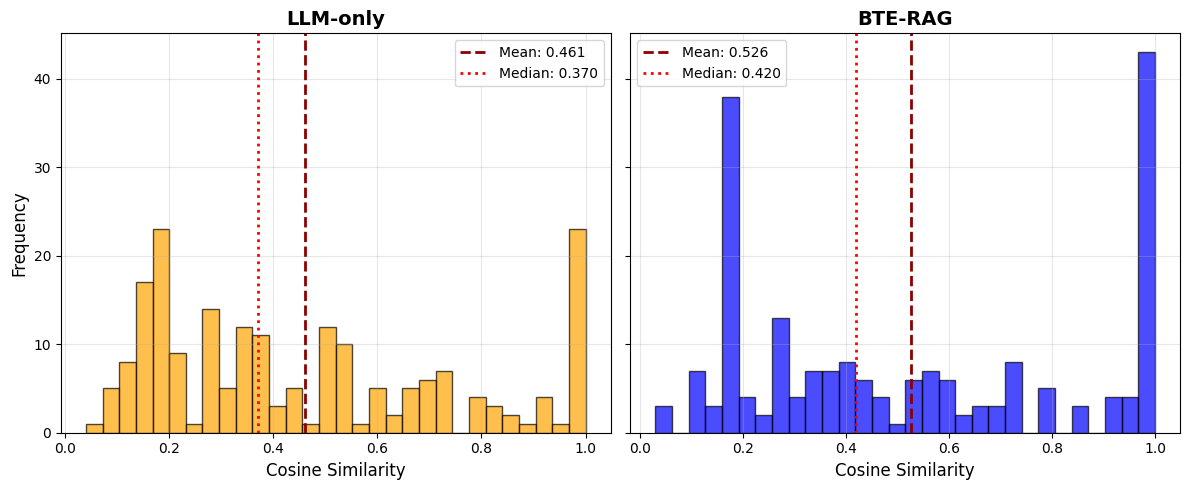

In [39]:
plot_side_by_side_histograms(baseline, rag)

2. Overlapping distributions...


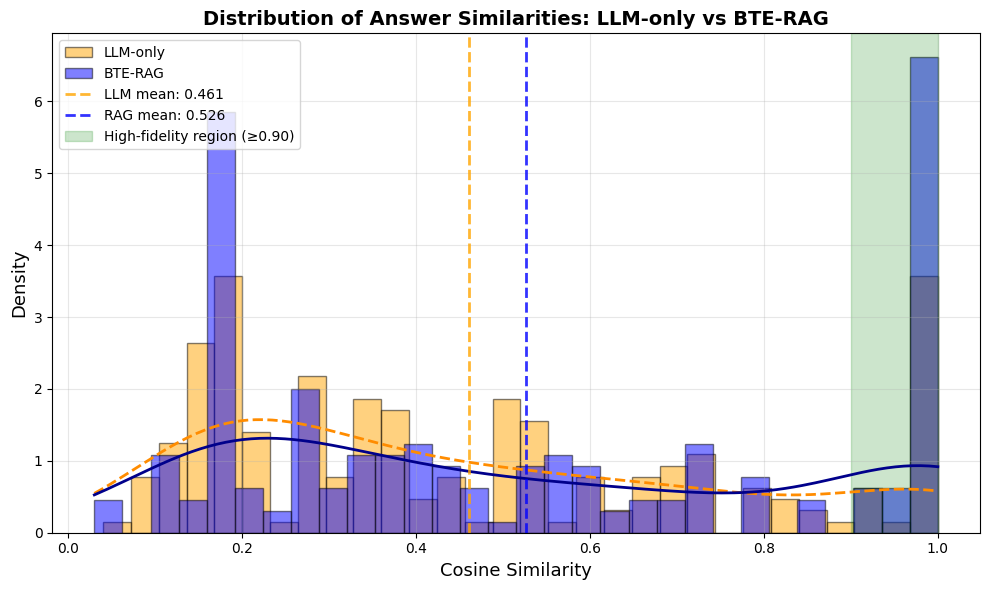

In [41]:
print("2. Overlapping distributions...")
plot_overlapping_distributions(baseline, rag)
    
   

3. Paired scatter plot...


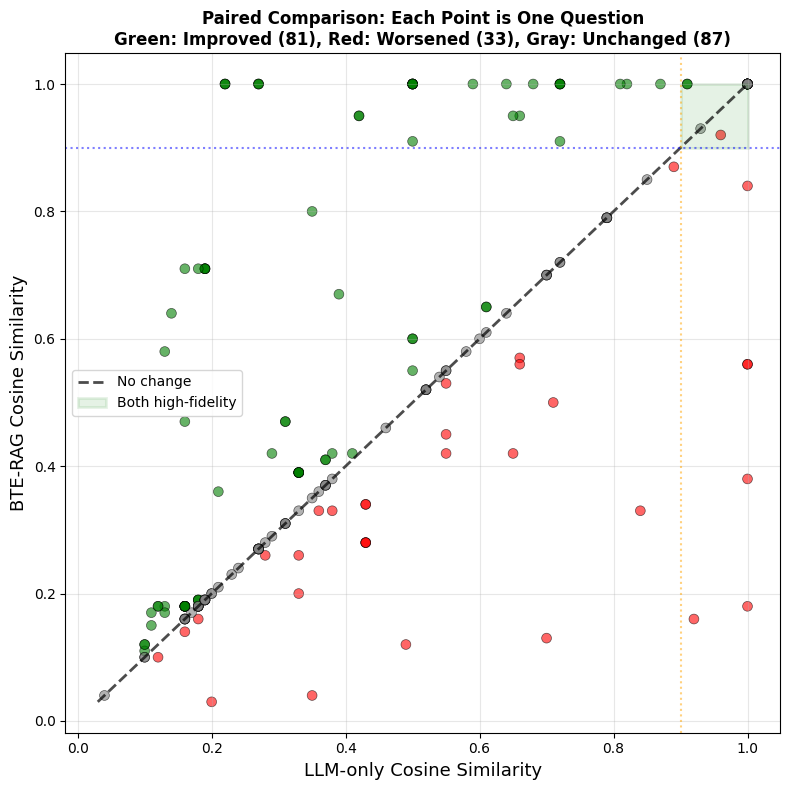

In [42]:
print("3. Paired scatter plot...")
plot_paired_scatter(baseline, rag)



4. Cumulative distribution...


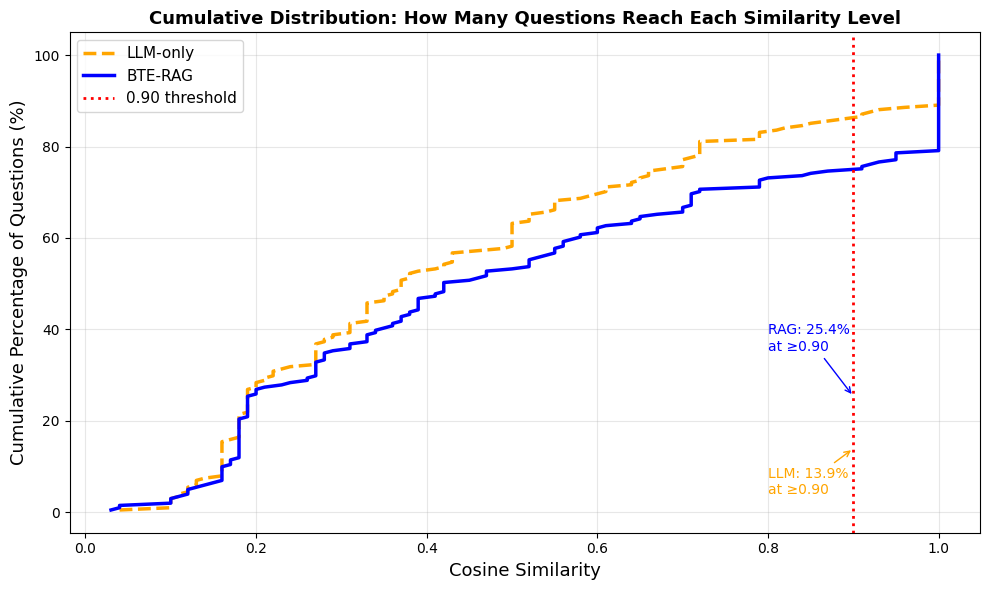

In [43]:
print("4. Cumulative distribution...")
plot_cumulative_comparison(baseline, rag)



6. Comprehensive summary figure...


/tmp/ipykernel_555988/1873749436.py:306: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(box_data, labels=['LLM-only', 'BTE-RAG'], patch_artist=True)


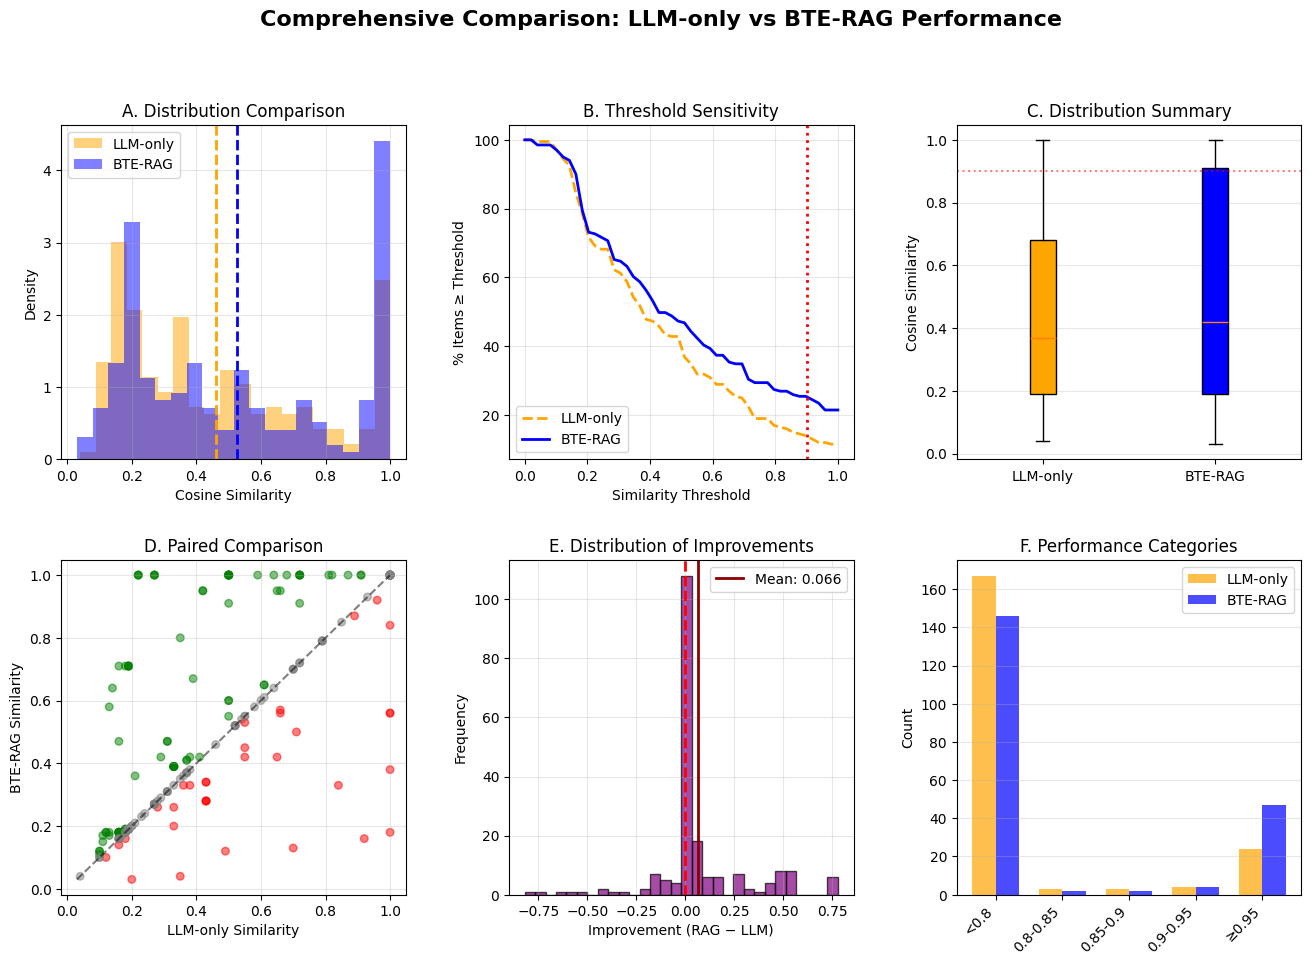

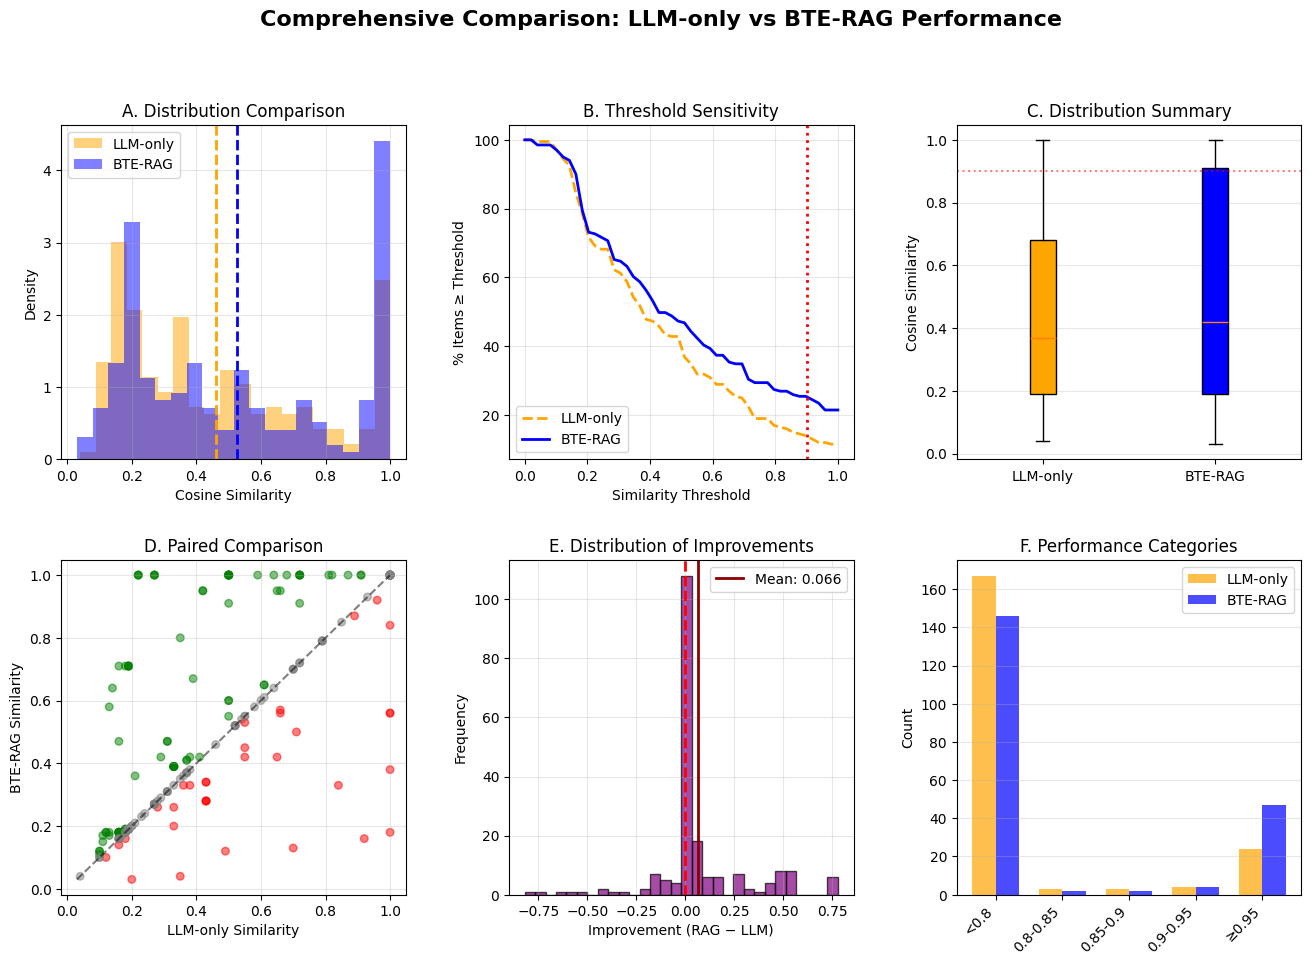

In [45]:
print("6. Comprehensive summary figure...")
create_summary_figure(baseline, rag)

